## Problem Statement

For this particular assignment, the data of different types of wine sales in the 20th century is to be analysed. Both of these data are from the same company but of different wines. As an analyst in the ABC Estate Wines, you are tasked to analyse and forecast Wine Sales in the 20th century.

## Importing necessary libraries

In [ ]:
from statsmodels.tsa.arima.model import ARIMA as ar
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
import statsmodels as st
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA
import itertools
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
#import plotly.offline as py

%matplotlib inline
import seaborn as sns
from pylab import rcParams

import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [ ]:
#mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Loading data
data = pd.read_csv('/content/drive/MyDrive/Deakin University/Time Series Analysis/Project/Sparkling.csv')

## Data Overview

In [ ]:
# Function to perform the data overview: shape, info, describe, missing vakues, duplicates, head and tail

from IPython.display import display, HTML
def display_dataframe_info(data_display, df_name="Your Dataframe Name", title="Dataframe Information"):
    """
    Displays detailed information about a dataframe using IPython.display and formatting.

    Args:
        data_display: The Pandas DataFrame to analyze.
        title (optional): A title for the displayed information.
        df_name (optional): The name of the dataframe to display after the title.

    Returns:
        None
    """
    display(HTML(f"<h1 style='font-weight: bold'>{title} for {df_name}</h1>"))

    # Display shape, info and description

    display(HTML(f"<p style='font-weight: bold'>Shape:</p>"))
    display(data_display.shape)
    display(HTML(f"<p style='font-weight: bold'>Information:</p>"))
    display(data_display.info())
    display(HTML(f"<p style='font-weight: bold'>Description:</p>"))
    display(data_display.describe(include = "all").T)

    # Display head and tail

    display(HTML(f"<p style='font-weight: bold'>Head (First 5 rows):</p>"))
    display(data_display.head())
    display(HTML(f"<p style='font-weight: bold'>Tail (Last 5 rows):</p>"))
    display(data_display.tail())

    # Display duplicates

    duplicate_count = data_display.duplicated().sum()
    display(HTML(f"<p style='font-weight: bold'>Duplicates:</p>"))
    display(f"Number of duplicate rows: {duplicate_count}")

    # Optionally show specific duplicates

    if duplicate_count > 0:
        display(HTML(f"<p style='font-weight: bold'>Duplicate Rows:</p>"))
        display(data_display[data_display.duplicated()])

    # Display missing values

    display(HTML(f"<p style='font-weight: bold'>Missing Values:</p>"))
    missing_values_df = data_display.isnull().sum().reset_index(name="Count")
    missing_values_df["Percentage"] = (
        missing_values_df["Count"] / data_display.shape[0]
    ) * 100
    top_missing_values = missing_values_df.nlargest(5, "Count").rename(
        columns={"index": "Column Name"}
    )
    display(top_missing_values)


In [ ]:
display_dataframe_info(data,"ABC Estate Wines", "Wine Sales Forecast")

(187, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   YearMonth  187 non-null    object
 1   Sparkling  187 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YearMonth,187,187,1980-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sparkling,187.0,NaN,NaN,NaN,2402.417112,1295.11154,1070.0,1605.0,1874.0,2549.0,7242.0


,YearMonth,Sparkling
0,1980-01,1686
1,1980-02,1591
2,1980-03,2304
3,1980-04,1712
4,1980-05,1471


,YearMonth,Sparkling
182,1995-03,1897
183,1995-04,1862
184,1995-05,1670
185,1995-06,1688
186,1995-07,2031


'Number of duplicate rows: 0'

,Column Name,Count,Percentage
0,YearMonth,0,0.0
1,Sparkling,0,0.0


In [ ]:
# Checking for null values
data.isnull().sum()

,0
YearMonth,0
Sparkling,0


In [ ]:
# Checking for NaN's
data.isna().sum()

,0
YearMonth,0
Sparkling,0


In [ ]:
# Checking notNA values
data.notna().sum()

,0
YearMonth,187
Sparkling,187


In [ ]:
data[data.isna().any(axis=1)]

,YearMonth,Sparkling


**Observations**:

*   There are 2 variables and 187 rows of data.
*   The data is from January 1980 to July 1995, approximately 15 years of wine sales data.
*  There is no duplicate data.
*  There is no missing data.
*  The YearMonth is an object, this needs to be converted to Time Series Data to be used in the modelling.








## Creating the Time Stamps and adding to the data frame to make it a Time Series Data

In [ ]:
# Create a date range for the duration of the dataset
date = pd.date_range(start='1/1/1980', end='08/1/1995', freq='M')
date

DatetimeIndex(['1980-01-31', '1980-02-29', '1980-03-31', '1980-04-30',
               '1980-05-31', '1980-06-30', '1980-07-31', '1980-08-31',
               '1980-09-30', '1980-10-31',
               ...
               '1994-10-31', '1994-11-30', '1994-12-31', '1995-01-31',
               '1995-02-28', '1995-03-31', '1995-04-30', '1995-05-31',
               '1995-06-30', '1995-07-31'],
              dtype='datetime64[ns]', length=187, freq='ME')

In [ ]:
# Adding the time stamp to the data frame
data['Time_Stamp'] = pd.DataFrame(date)
data.head()

,YearMonth,Sparkling,Time_Stamp
0,1980-01,1686,1980-01-31
1,1980-02,1591,1980-02-29
2,1980-03,2304,1980-03-31
3,1980-04,1712,1980-04-30
4,1980-05,1471,1980-05-31


In [ ]:
# Setting the time stamp as the index
data.set_index('Time_Stamp',inplace=True)
data.head()

,YearMonth,Sparkling
Time_Stamp,,
1980-01-31,1980-01,1686
1980-02-29,1980-02,1591
1980-03-31,1980-03,2304
1980-04-30,1980-04,1712
1980-05-31,1980-05,1471


In [ ]:
# Dropping the YearMonth column as it is no longer needed
data.drop('YearMonth',axis=1,inplace=True)
data.head()

,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


In [ ]:
# Drop the row with NaT index
data.dropna(inplace=True)

# Set the frequency of the DatetimeIndex directly to Month End
data.index.freq = 'ME'

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 187 entries, 1980-01-31 to 1995-07-31
Freq: ME
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Sparkling  187 non-null    int64
dtypes: int64(1)
memory usage: 2.9 KB


In [ ]:
# making a copy of the data
df = data.copy()
df.head()

,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


In [ ]:
df.tail()

,Sparkling
Time_Stamp,
1995-03-31,1897
1995-04-30,1862
1995-05-31,1670
1995-06-30,1688
1995-07-31,2031


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sparkling,187.0,2402.417112,1295.11154,1070.0,1605.0,1874.0,2549.0,7242.0


**Observations**
*  The mean sales is approx. 2402.
*  The range of sales is from approx 1070 to 7242 with 50% sales in 1874.  As the mean is greater than the median and even the 75% is close to the mean the data appears to be right skewed.

## Exploratory Data Analysis (EDA)


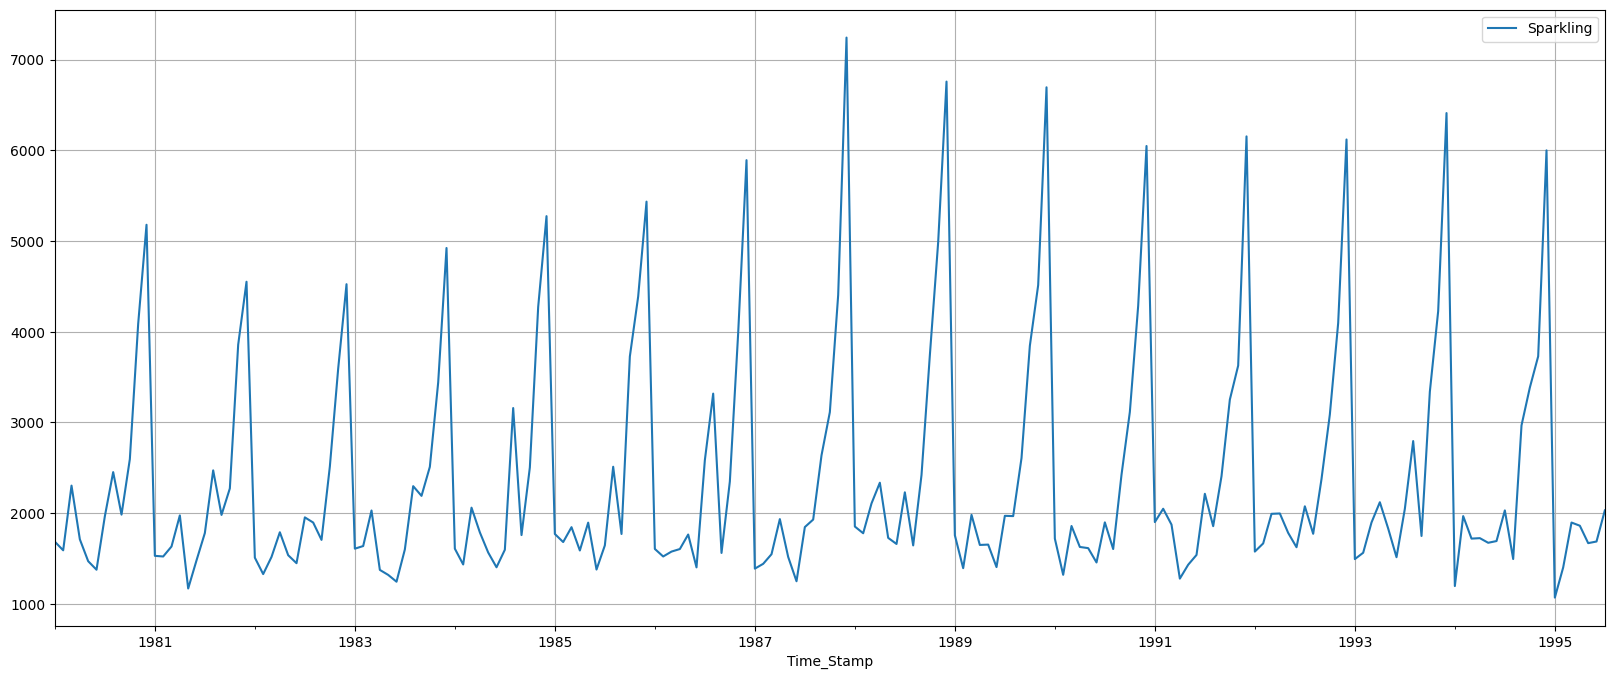

In [ ]:
## Plotting the time series

df.plot(figsize=(20,8))
plt.grid();

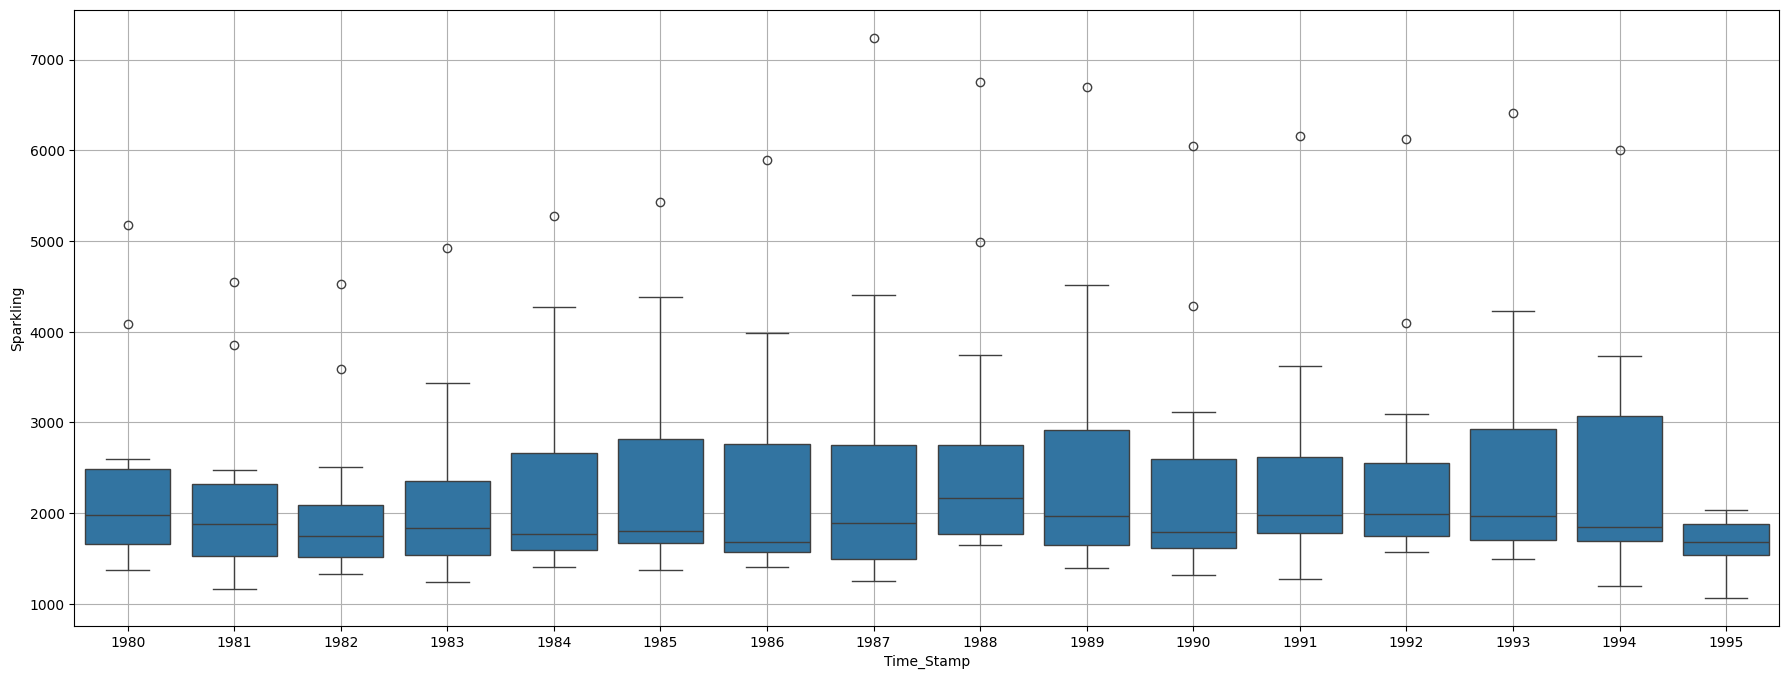

In [ ]:
#Plotting Yearly Box-Plot
fig, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x = df.index.year,y = df['Sparkling'])
plt.grid();

**Observations**
*  We see the sales of sparkling fluctuates. In 1984 to 1989 there are higher sales  after this the sles decreased and then in 1993 the sales increased again.
* From this boxplot there is no clearly visable trend.

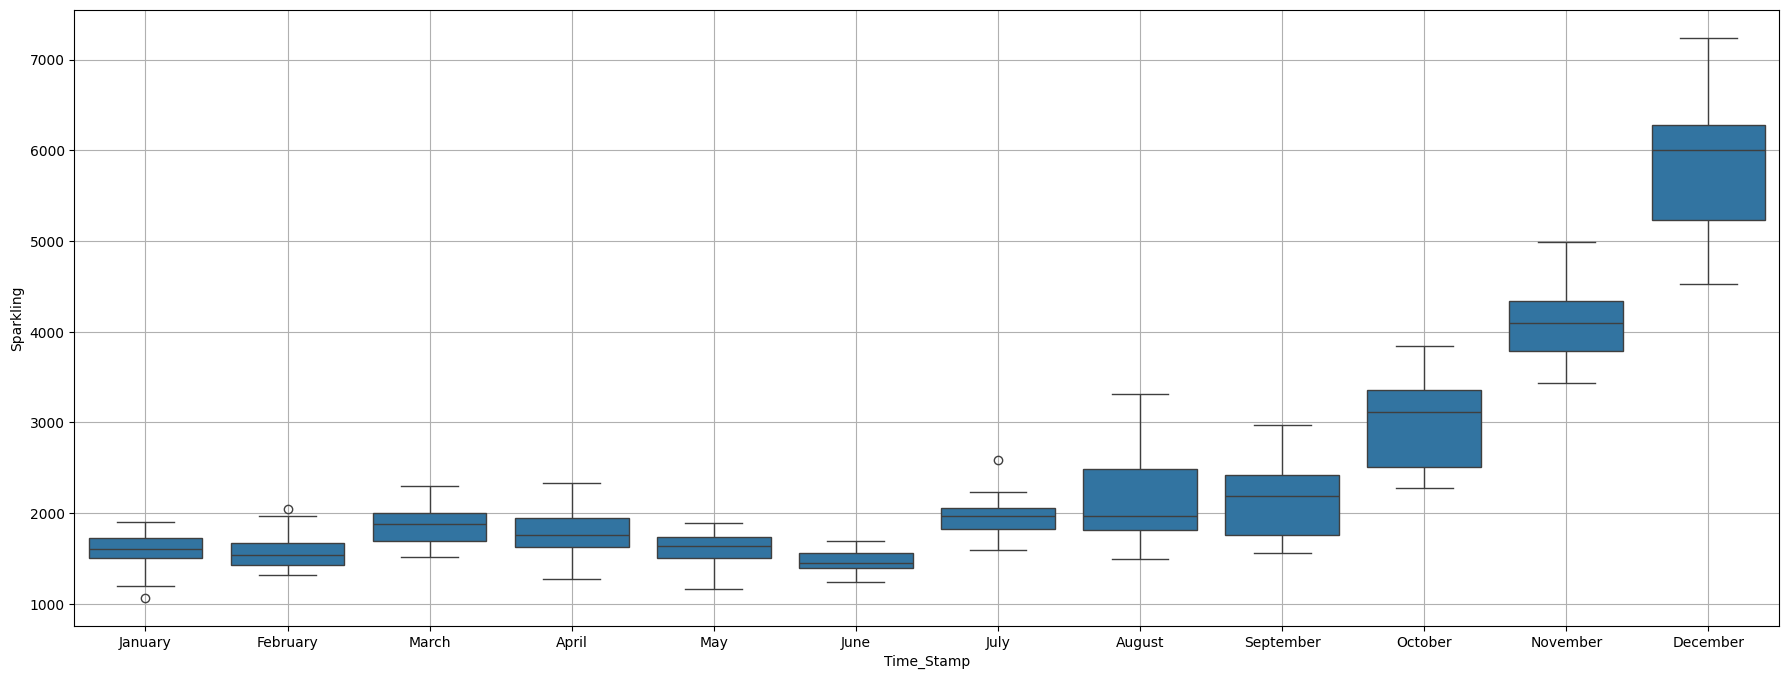

In [ ]:
#Plotting Monthly Box_Plot
fig, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x = df.index.month_name(),y = df['Sparkling'])
plt.grid();

**Observations**
*  We see that sales tends to increase in the second half of the year.  
*  In July and August there is a small increase in sales compared to the previous months.
*  In October, November and December there is a larger increase in sales, where November is double and December triple the sales in the first few months of the year.
*  This pattern suggests there is seasonality in the data

### Plot a time series monthplot to understand the spread of wine sales across different years and within different months across years.

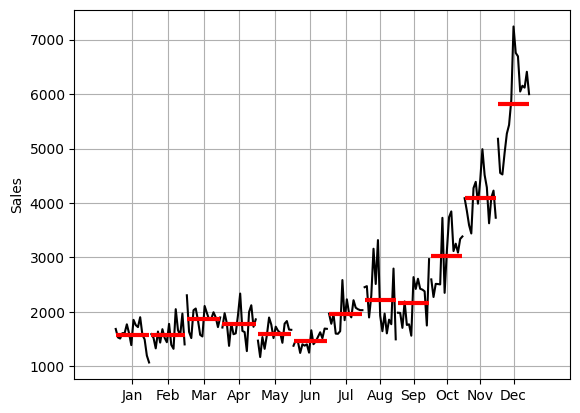

In [ ]:
from statsmodels.graphics.tsaplots import month_plot

month_plot(df['Sparkling'],ylabel='Sales')
plt.grid();

**Observations**

* We see in August there is a smaller increase in sales.
*  Starting from October, sales increases up to December.
*  In December the sales are more than tripple the sales in January

### Plot monthly sales across years

In [ ]:
#making a pivot table
monthly_sales_across_years = pd.pivot_table(df, values = 'Sparkling', columns = df.index.month_name(), index = df.index.year)
monthly_sales_across_years

Time_Stamp,April,August,December,February,January,July,June,March,May,November,October,September
Time_Stamp,,,,,,,,,,,,
1980,1712.0,2453.0,5179.0,1591.0,1686.0,1966.0,1377.0,2304.0,1471.0,4087.0,2596.0,1984.0
1981,1976.0,2472.0,4551.0,1523.0,1530.0,1781.0,1480.0,1633.0,1170.0,3857.0,2273.0,1981.0
1982,1790.0,1897.0,4524.0,1329.0,1510.0,1954.0,1449.0,1518.0,1537.0,3593.0,2514.0,1706.0
1983,1375.0,2298.0,4923.0,1638.0,1609.0,1600.0,1245.0,2030.0,1320.0,3440.0,2511.0,2191.0
1984,1789.0,3159.0,5274.0,1435.0,1609.0,1597.0,1404.0,2061.0,1567.0,4273.0,2504.0,1759.0
1985,1589.0,2512.0,5434.0,1682.0,1771.0,1645.0,1379.0,1846.0,1896.0,4388.0,3727.0,1771.0
1986,1605.0,3318.0,5891.0,1523.0,1606.0,2584.0,1403.0,1577.0,1765.0,3987.0,2349.0,1562.0
1987,1935.0,1930.0,7242.0,1442.0,1389.0,1847.0,1250.0,1548.0,1518.0,4405.0,3114.0,2638.0
1988,2336.0,1645.0,6757.0,1779.0,1853.0,2230.0,1661.0,2108.0,1728.0,4988.0,3740.0,2421.0


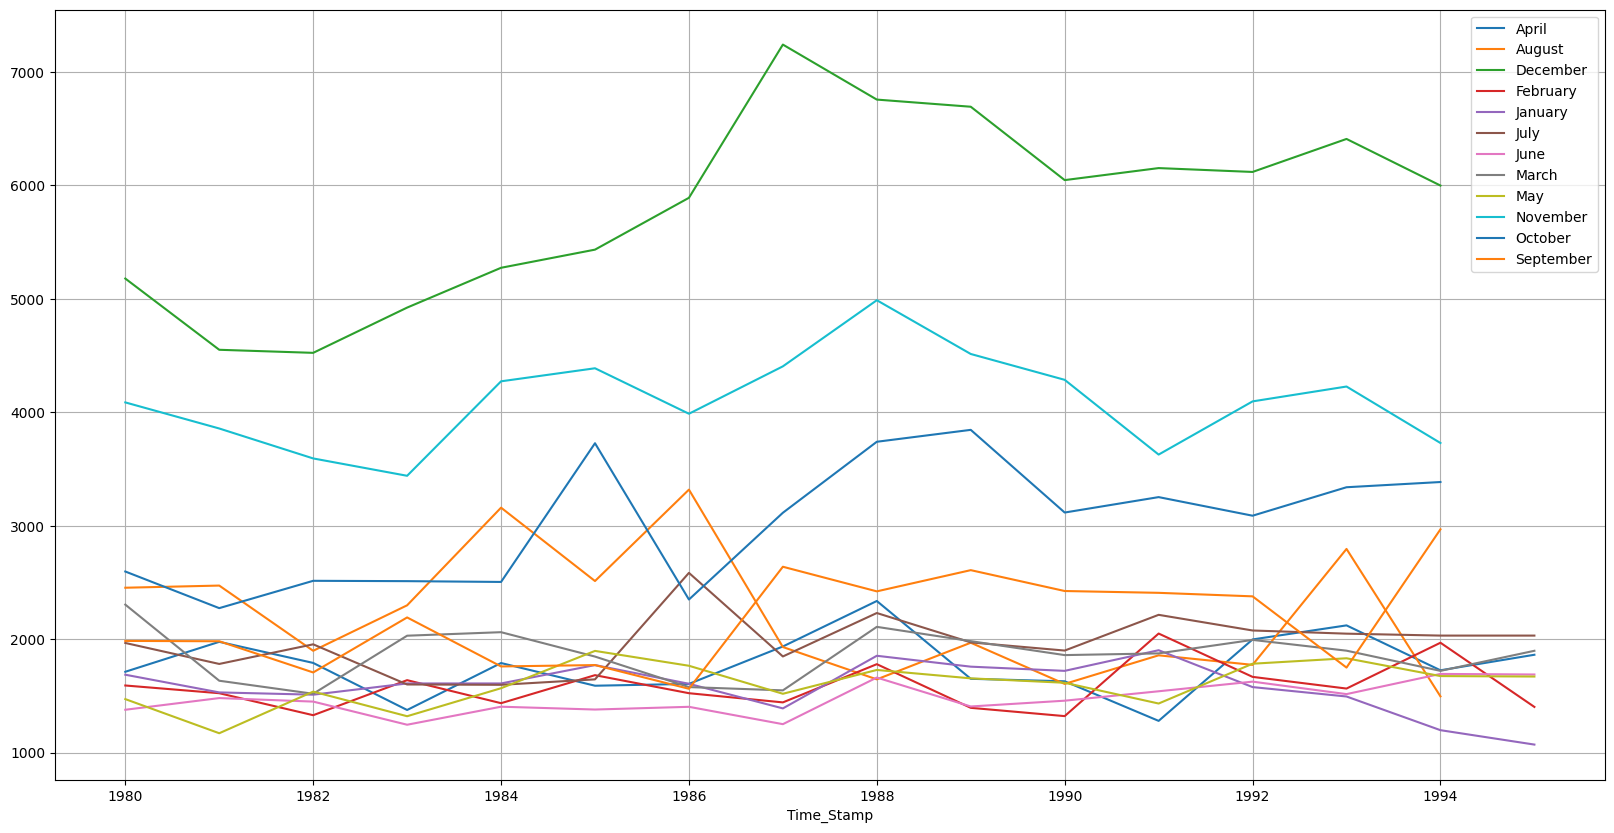

In [ ]:
monthly_sales_across_years.plot(figsize=(20,10))
plt.grid()
plt.legend(loc='best');

**Observation**
*  We can see that December has the highest sales.
*  November has the second highest sales followed by October.

## Plot the Empirical Cumulative Distribution.

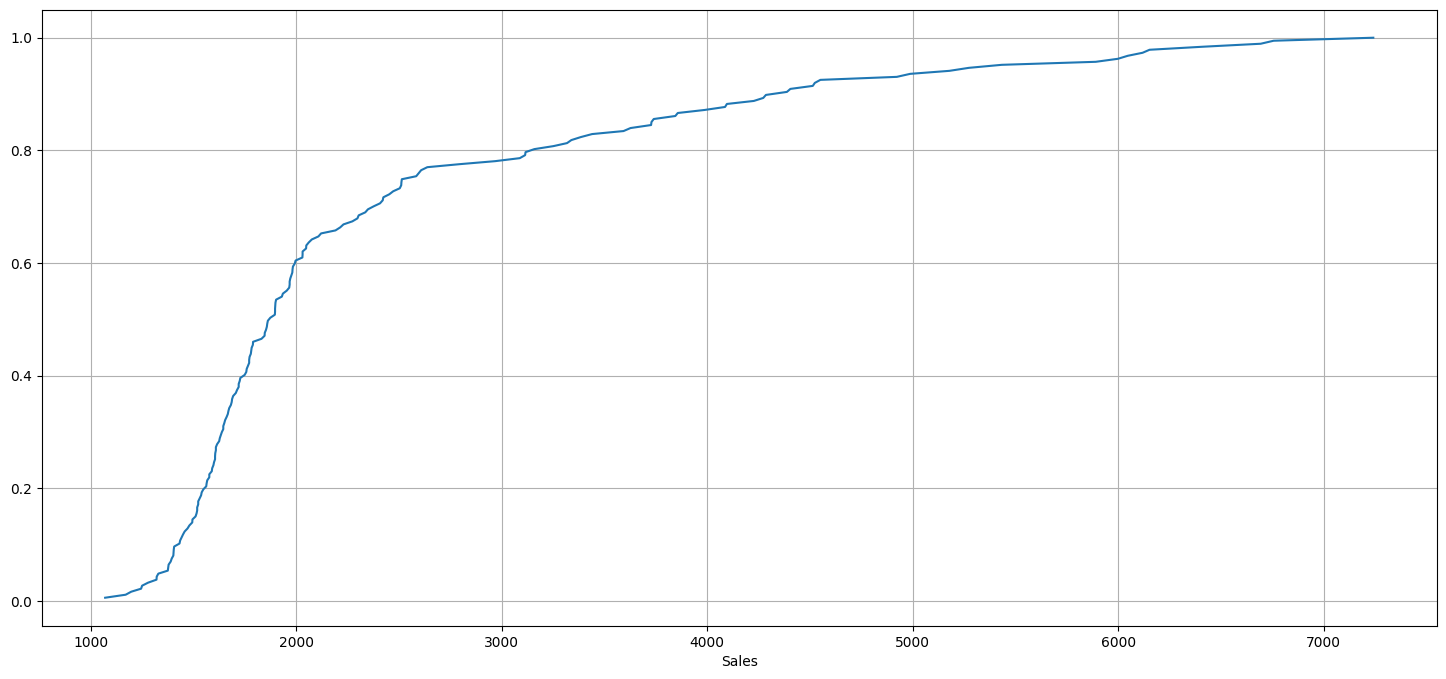

In [ ]:
# statistics
from statsmodels.distributions.empirical_distribution import ECDF

plt.figure(figsize = (18, 8))
cdf = ECDF(df['Sparkling'])
plt.plot(cdf.x, cdf.y, label = "statmodels");
plt.grid()
plt.xlabel('Sales');

**Observations**

We see that approximately 85% of the monthly sales are below 4000

## Plot the average Sparkling sales per month and the month on month percentage change of Sparkling sales.

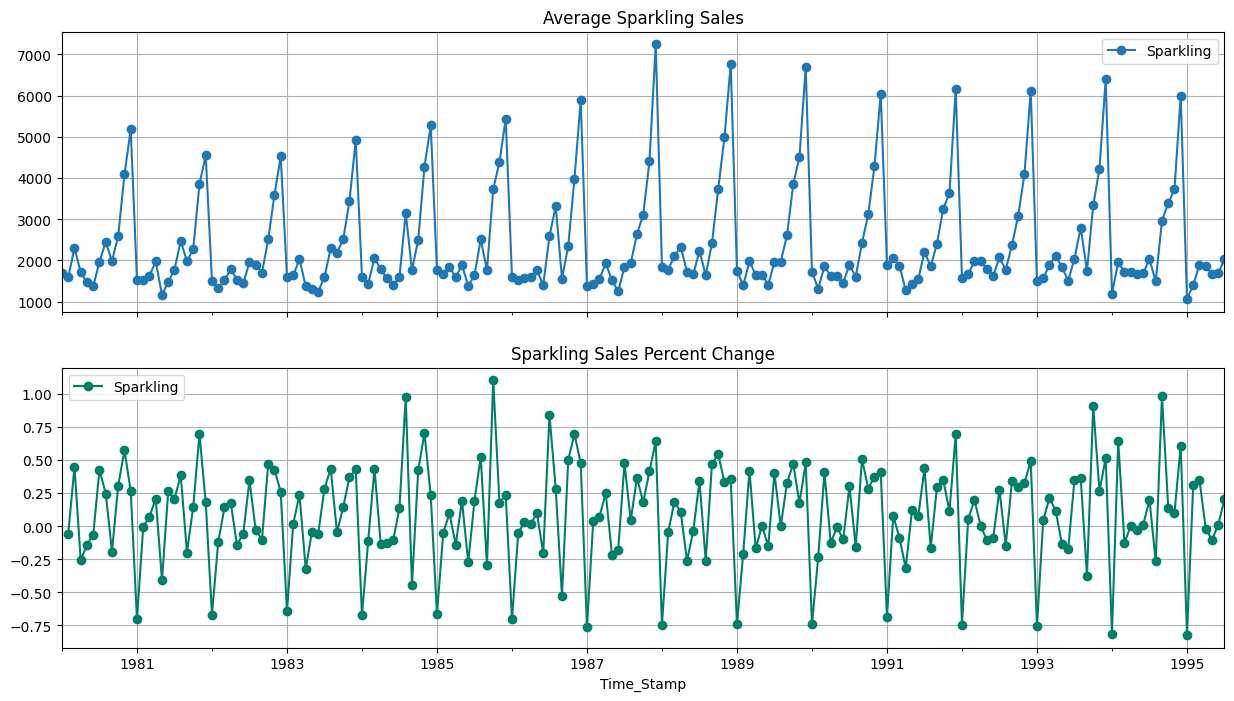

In [ ]:
# group by date and get average RetailSales, and precent change
average    = df.groupby(df.index)["Sparkling"].mean()
pct_change = df.groupby(df.index)["Sparkling"].sum().pct_change()

fig, (axis1,axis2) = plt.subplots(2,1,sharex=True,figsize=(15,8))

# plot average RetailSales over time(year-month)
ax1 = average.plot(legend=True,ax=axis1,marker='o',title="Average Sparkling Sales",grid=True)
ax1.set_xticks(range(len(average)))
ax1.set_xticklabels(average.index.tolist())
# plot precent change for RetailSales over time(year-month)
ax2 = pct_change.plot(legend=True,ax=axis2,marker='o',colormap="summer",title="Sparkling Sales Percent Change",grid=True)

**Observations**
* The average retail sales increases after 1987.
* The Percentage change in sales shows us that during the year the sales increases and decreases.  It appears that at the start of the year the percentage change is the least.

## Outlier Detection

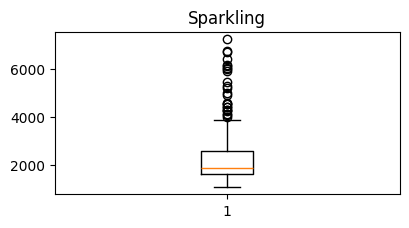

In [ ]:
# outlier detection using boxplot
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(6, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observations**
There are outliers in the dataset.  However there is not enough information to decide if there are exaplinable.  Hence we will not treat outliers

# Decomposing the time series

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 187 entries, 1980-01-31 to 1995-07-31
Freq: ME
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Sparkling  187 non-null    int64
dtypes: int64(1)
memory usage: 2.9 KB


# Additive Decomposition

<Figure size 2000x800 with 0 Axes>

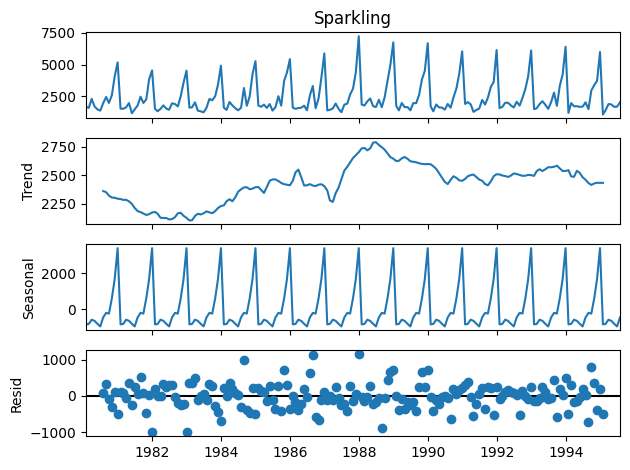

In [ ]:
decomposition = seasonal_decompose(df['Sparkling'],model='additive')
plt.figure(figsize=(20, 8))
decomposition.plot();

In [ ]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

Trend 
 Time_Stamp
1980-01-31            NaN
1980-02-29            NaN
1980-03-31            NaN
1980-04-30            NaN
1980-05-31            NaN
1980-06-30            NaN
1980-07-31    2360.666667
1980-08-31    2351.333333
1980-09-30    2320.541667
1980-10-31    2303.583333
1980-11-30    2302.041667
1980-12-31    2293.791667
Freq: ME, Name: trend, dtype: float64 

Seasonality 
 Time_Stamp
1980-01-31    -854.260599
1980-02-29    -830.350678
1980-03-31    -592.356630
1980-04-30    -658.490559
1980-05-31    -824.416154
1980-06-30    -967.434011
1980-07-31    -465.502265
1980-08-31    -214.332821
1980-09-30    -254.677265
1980-10-31     599.769957
1980-11-30    1675.067179
1980-12-31    3386.983846
Freq: ME, Name: seasonal, dtype: float64 

Residual 
 Time_Stamp
1980-01-31           NaN
1980-02-29           NaN
1980-03-31           NaN
1980-04-30           NaN
1980-05-31           NaN
1980-06-30           NaN
1980-07-31     70.835599
1980-08-31    315.999487
1980-09-30    -81.864401
19

# Multiplicative Decomposition

<Figure size 2000x800 with 0 Axes>

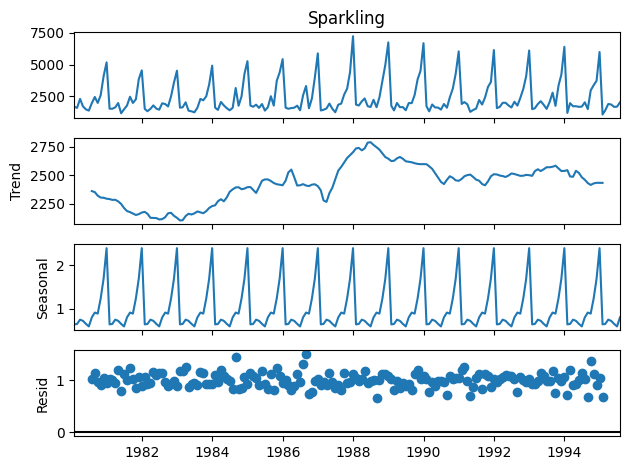

In [ ]:
decomposition = seasonal_decompose(df['Sparkling'],model='multiplicative')
plt.figure(figsize=(20, 8))
decomposition.plot();

In [ ]:
trend = decomposition.trend
seasonality = decomposition.seasonal
residual = decomposition.resid

print('Trend','\n',trend.head(12),'\n')
print('Seasonality','\n',seasonality.head(12),'\n')
print('Residual','\n',residual.head(12),'\n')

Trend 
 Time_Stamp
1980-01-31            NaN
1980-02-29            NaN
1980-03-31            NaN
1980-04-30            NaN
1980-05-31            NaN
1980-06-30            NaN
1980-07-31    2360.666667
1980-08-31    2351.333333
1980-09-30    2320.541667
1980-10-31    2303.583333
1980-11-30    2302.041667
1980-12-31    2293.791667
Freq: ME, Name: trend, dtype: float64 

Seasonality 
 Time_Stamp
1980-01-31    0.649843
1980-02-29    0.659214
1980-03-31    0.757440
1980-04-30    0.730351
1980-05-31    0.660609
1980-06-30    0.603468
1980-07-31    0.809164
1980-08-31    0.918822
1980-09-30    0.894367
1980-10-31    1.241789
1980-11-30    1.690158
1980-12-31    2.384776
Freq: ME, Name: seasonal, dtype: float64 

Residual 
 Time_Stamp
1980-01-31         NaN
1980-02-29         NaN
1980-03-31         NaN
1980-04-30         NaN
1980-05-31         NaN
1980-06-30         NaN
1980-07-31    1.029230
1980-08-31    1.135407
1980-09-30    0.955954
1980-10-31    0.907513
1980-11-30    1.050423
1980-12-31

# Checking for Stationarity of the whole time series data

In [ ]:
## Test for stationarity of the series - Dicky Fuller test

from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(window=7).mean() #determining the rolling mean
    rolstd = timeseries.rolling(window=7).std()   #determining the rolling standard deviation

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput,'\n')

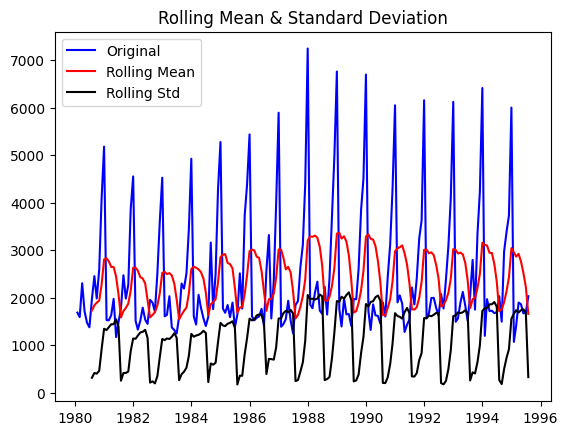

Results of Dickey-Fuller Test:
Test Statistic                  -1.360497
p-value                          0.601061
#Lags Used                      11.000000
Number of Observations Used    175.000000
Critical Value (1%)             -3.468280
Critical Value (5%)             -2.878202
Critical Value (10%)            -2.575653
dtype: float64 



In [ ]:
test_stationarity(df['Sparkling'])

**Observations**
*  We see that the rolling standard deviation is different from the rolling mean and the original data.  
*  The p-value is 0.601, hence at a 5% significant level the time series is non-stationary

## Differeicing of order 1 to see if the series becomes stationary

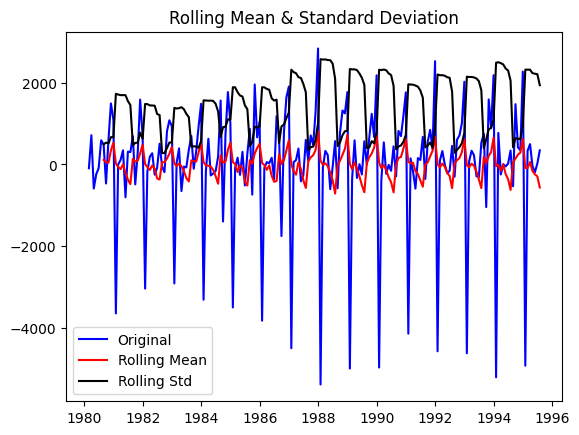

Results of Dickey-Fuller Test:
Test Statistic                 -45.050301
p-value                          0.000000
#Lags Used                      10.000000
Number of Observations Used    175.000000
Critical Value (1%)             -3.468280
Critical Value (5%)             -2.878202
Critical Value (10%)            -2.575653
dtype: float64 



In [ ]:
test_stationarity(df['Sparkling'].diff().dropna())

**Oservations**
*  All three graphs are now overlapping.
*  The p-value is 0.00
*  At a 5% siginificant level the time series is stationary

## Plotting the Auto-Correlation function plots on the whole data

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

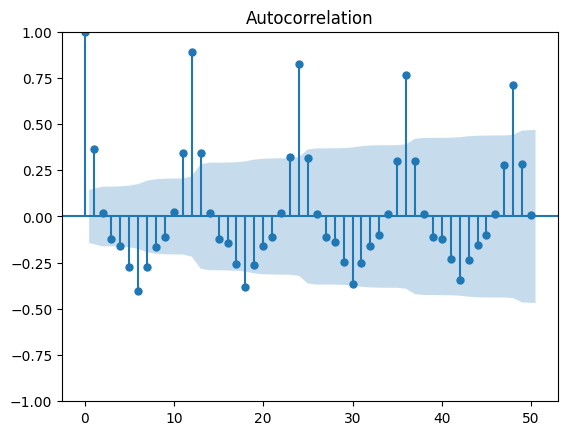

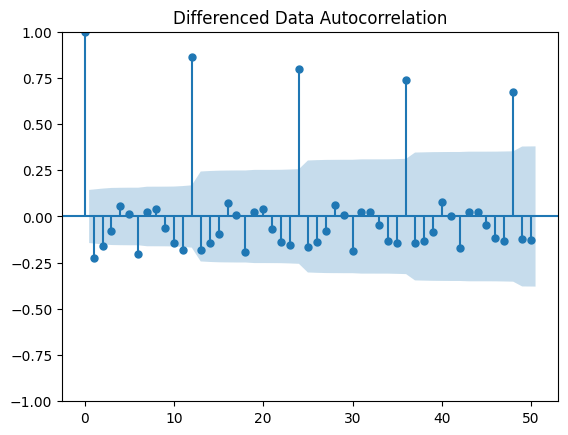

In [ ]:
plot_acf(df['Sparkling'],lags=50)
plot_acf(df['Sparkling'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plt.show()

**Observations**
* From the ACF plots we can see that there is seasonality in the time series.  It appears to be every 12 months.

## Data Preparation for Modeling


### Splitting the data into Training and Testing data

In [ ]:
train=df[df.index.year < 1993]
test=df[df.index.year >= 1993]

In [ ]:
## This is to display multiple data frames from one cell
from IPython.display import display

In [ ]:
print('First few rows of Training Data')
display(train.head())
print('Last few rows of Training Data')
display(train.tail())
print('First few rows of Test Data')
display(test.head())
print('Last few rows of Test Data')
display(test.tail())

First few rows of Training Data


,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


Last few rows of Training Data


,Sparkling
Time_Stamp,
1992-08-31,1773
1992-09-30,2377
1992-10-31,3088
1992-11-30,4096
1992-12-31,6119


First few rows of Test Data


,Sparkling
Time_Stamp,
1993-01-31,1494
1993-02-28,1564
1993-03-31,1898
1993-04-30,2121
1993-05-31,1831


Last few rows of Test Data


,Sparkling
Time_Stamp,
1995-03-31,1897
1995-04-30,1862
1995-05-31,1670
1995-06-30,1688
1995-07-31,2031


In [ ]:
# Checking the shape of the training and test data set
print(train.shape)
print(test.shape)

(156, 1)
(31, 1)


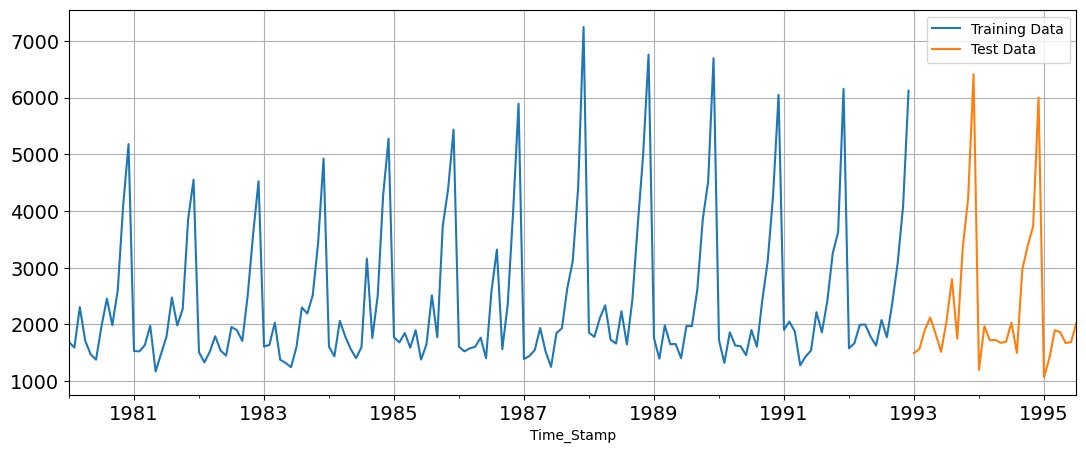

In [ ]:
# Plotting Train and Trest datasets
train['Sparkling'].plot(figsize=(13,5), fontsize=14)
test['Sparkling'].plot(figsize=(13,5), fontsize=14)
plt.grid()
plt.legend(['Training Data','Test Data'])
plt.show()

### Checking for Stationarity in the Training Data

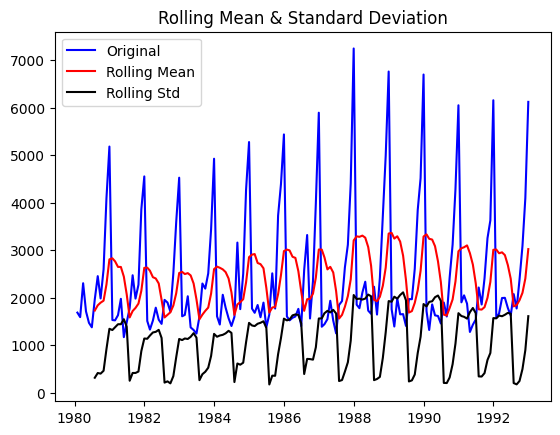

Results of Dickey-Fuller Test:
Test Statistic                  -1.323320
p-value                          0.618437
#Lags Used                      12.000000
Number of Observations Used    143.000000
Critical Value (1%)             -3.476927
Critical Value (5%)             -2.881973
Critical Value (10%)            -2.577665
dtype: float64 



In [ ]:
test_stationarity(train['Sparkling'])

**Observations**
* The p-value is 0.618.  At a 5% significant level the training data is non-stationary.  

To train our ARIMA time series models the series needs to be stationary.  We will have to difference the time series to make it stationary in order to build the model on the training data.

## Model Building

## Method 1 - Regression Model
For this particular linear regression, we are going to regress the 'Sparkling' variable against the order of the occurrence. For this we need to modify our training data before fitting it into a linear regression.

In [ ]:
len(train)

156

In [ ]:
train_time = [i+1 for i in range(len(train))]
test_time = [i+len(train) for i in range(len(test))]
print('Training Time instance','\n',train_time)
print('Test Time instance','\n',test_time)

Training Time instance 
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156]
Test Time instance 
 [156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186]


We see that we have successfully the generated the numerical time instance order for both the training and test set. Now we will add these values in the training and test set.

In [ ]:
# Making a copy of the train and test data for the Linear Regression
LinearRegression_train = train.copy()
LinearRegression_test = test.copy()

In [ ]:
LinearRegression_train['time'] = train_time
LinearRegression_test['time'] = test_time

print('First few rows of Training Data','\n',LinearRegression_train.head(),'\n')
print('Last few rows of Training Data','\n',LinearRegression_train.tail(),'\n')
print('First few rows of Test Data','\n',LinearRegression_test.head(),'\n')
print('Last few rows of Test Data','\n',LinearRegression_test.tail(),'\n')

First few rows of Training Data 
             Sparkling  time
Time_Stamp                 
1980-01-31       1686     1
1980-02-29       1591     2
1980-03-31       2304     3
1980-04-30       1712     4
1980-05-31       1471     5 

Last few rows of Training Data 
             Sparkling  time
Time_Stamp                 
1992-08-31       1773   152
1992-09-30       2377   153
1992-10-31       3088   154
1992-11-30       4096   155
1992-12-31       6119   156 

First few rows of Test Data 
             Sparkling  time
Time_Stamp                 
1993-01-31       1494   156
1993-02-28       1564   157
1993-03-31       1898   158
1993-04-30       2121   159
1993-05-31       1831   160 

Last few rows of Test Data 
             Sparkling  time
Time_Stamp                 
1995-03-31       1897   182
1995-04-30       1862   183
1995-05-31       1670   184
1995-06-30       1688   185
1995-07-31       2031   186 



Now that our training and test data has been modified, let us go ahead use $\underline{Linear Regression}$ to build the model on the training data and test the model on the test data.

In [ ]:
# Importing the necessary libraries
from sklearn.linear_model import LinearRegression

# Creating an instance of the linear regression model
lr = LinearRegression()

# Fitting ther linear regression model to the training data
lr.fit(LinearRegression_train[['time']],LinearRegression_train['Sparkling'].values)

LinearRegression()

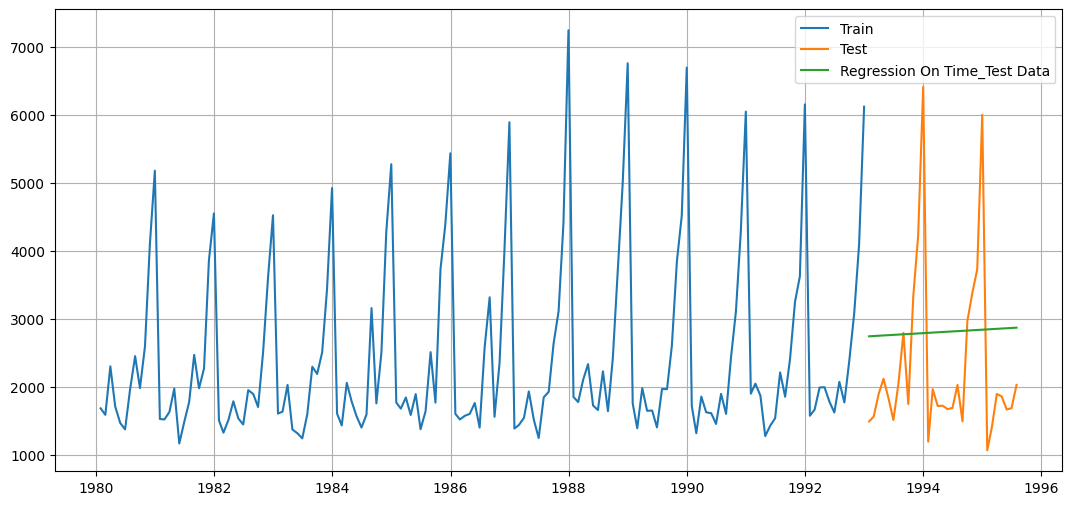

In [ ]:
# predicting
test_predictions_model1         = lr.predict(LinearRegression_test[['time']])
LinearRegression_test['RegOnTime'] = test_predictions_model1

plt.figure(figsize=(13,6))
plt.plot( train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')
plt.plot(LinearRegression_test['RegOnTime'], label='Regression On Time_Test Data')
plt.legend(loc='best')
plt.grid();

Defining accuracy matrix

In [ ]:
from sklearn import metrics

## Test Data - RMSE
mse = metrics.mean_squared_error(test['Sparkling'], test_predictions_model1)
rmse_model1_test = np.sqrt(mse)

print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.3f" % rmse_model1_test)

For RegressionOnTime forecast on the Test Data,  RMSE is 1342.993


#### Creating a dataframe to store all the results for model comparision

In [ ]:
resultsDf = pd.DataFrame({'Test RMSE': [rmse_model1_test]},index=['RegressionOnTime'])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772


**Observations**


We see that we can get a model to predict the sales of Sparkling wine.  The RMSE is 1342.99.  Let us build the remaining models and compare the RMSE to chose the best model.

## Method 2: Naive Approach: $\hat{y}_{t+1} = y_t$

For this particular naive model, we say that the prediction for tomorrow is the same as today and the prediction for day after tomorrow is tomorrow and since the prediction of tomorrow is same as today,therefore the prediction for day after tomorrow is also today.

In [ ]:
#  making a copy of the train and test data to perform the naive model

NaiveModel_train = train.copy()
NaiveModel_test = test.copy()

In [ ]:
NaiveModel_test['naive'] = np.asarray(train['Sparkling'])[len(np.asarray(train['Sparkling']))-1]
NaiveModel_test['naive'].head()

,naive
Time_Stamp,
1993-01-31,6119
1993-02-28,6119
1993-03-31,6119
1993-04-30,6119
1993-05-31,6119


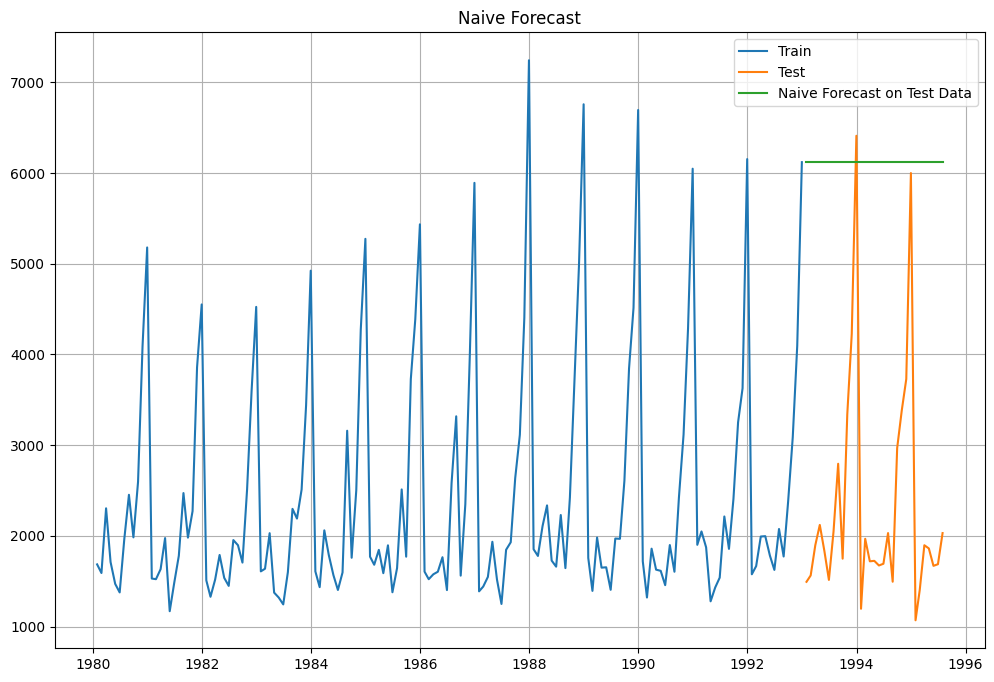

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(NaiveModel_train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')
plt.plot(NaiveModel_test['naive'], label='Naive Forecast on Test Data')
plt.legend(loc='best')
plt.title("Naive Forecast")
plt.grid();

### Model Evaluation

In [ ]:
## Test Data - RMSE

mse_model2_test = metrics.mean_squared_error(test['Sparkling'], NaiveModel_test['naive'])
rmse_model2_test = np.sqrt(mse_model2_test)

print("For NaiveModel forecast on the Test Data,  RMSE is %3.3f" % rmse_model2_test)

For NaiveModel forecast on the Test Data,  RMSE is 3992.533


In [ ]:
resultsDf_2 = pd.DataFrame({'Test RMSE': [rmse_model2_test]},index=['NaiveModel'])

resultsDf = pd.concat([resultsDf, resultsDf_2])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732


**Observations**

The RMSE for the Naive model is higher than the regression model.  This is expected as the model is using the previous days sales to predict tomorrow sales.

## Method 3: Simple Average
#### For this particular simple average method, we will forecast by using the average of the training values.

In [ ]:
# Making a copy of the train and test data to perform the Simple Average model
SimpleAverage_train = train.copy()
SimpleAverage_test = test.copy()

In [ ]:
SimpleAverage_test['mean_forecast'] = train['Sparkling'].mean()
SimpleAverage_test.head()

,Sparkling,mean_forecast
Time_Stamp,,
1993-01-31,1494,2417.032051
1993-02-28,1564,2417.032051
1993-03-31,1898,2417.032051
1993-04-30,2121,2417.032051
1993-05-31,1831,2417.032051


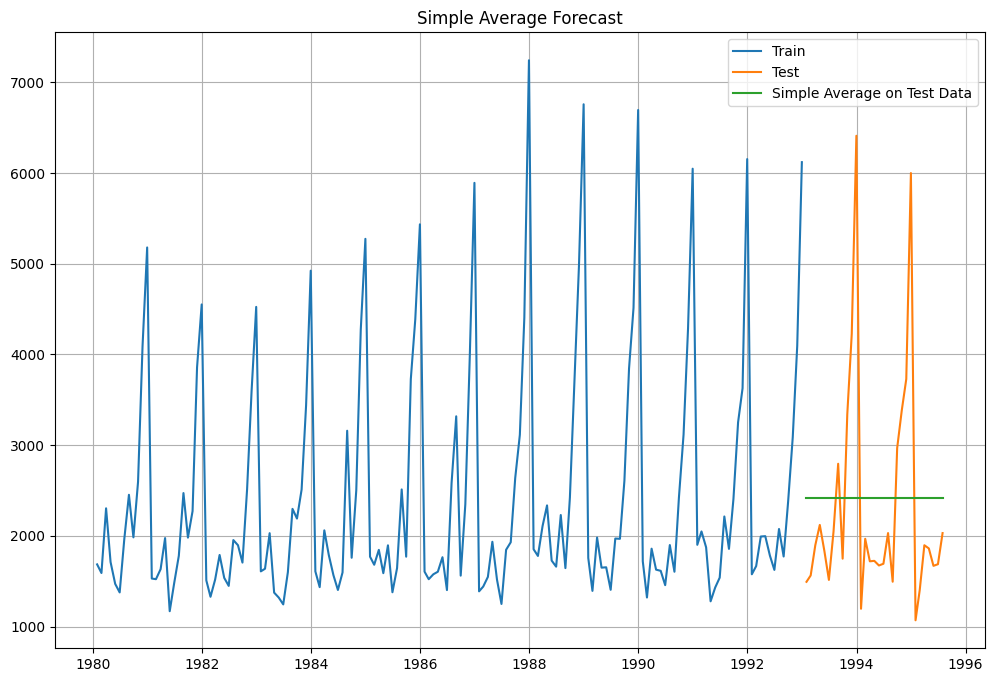

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(SimpleAverage_train['Sparkling'], label='Train')
plt.plot(SimpleAverage_test['Sparkling'], label='Test')
plt.plot(SimpleAverage_test['mean_forecast'], label='Simple Average on Test Data')
plt.legend(loc='best')
plt.title("Simple Average Forecast")
plt.grid();

### Model Evaluation

In [ ]:
## Test Data - RMSE
mse_model3_test = metrics.mean_squared_error(test['Sparkling'], SimpleAverage_test['mean_forecast'])
rmse_model3_test = np.sqrt(mse_model3_test)

print("For Simple Average forecast on the Test Data,  RMSE is %3.3f" % rmse_model3_test)

For Simple Average forecast on the Test Data,  RMSE is 1258.178


In [ ]:
resultsDf_3 = pd.DataFrame({'Test RMSE': [rmse_model3_test]},index=['SimpleAverageModel'])

resultsDf = pd.concat([resultsDf, resultsDf_3])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011


**Observations**

The simple Average model is giving the best RMSE so far.  This model uses the average of the training dataset to predict.  Let continue building the models and compare the RMSE.

## Method 4: Moving Average(MA)

#### For the moving average model, we are going to calculate rolling means (or moving averages) for different intervals. The best interval can be determined by the maximum accuracy (or the minimum error) over here.

###### For Moving Average, we are going to average over the entire data.

In [ ]:
MovingAverage = df.copy()
MovingAverage.head()

,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


In [ ]:

MovingAverage['Trailing_2'] = MovingAverage['Sparkling'].rolling(2).mean()
MovingAverage['Trailing_4'] = MovingAverage['Sparkling'].rolling(4).mean()
MovingAverage['Trailing_6'] = MovingAverage['Sparkling'].rolling(6).mean()
MovingAverage['Trailing_9'] = MovingAverage['Sparkling'].rolling(9).mean()

MovingAverage.head()

,Sparkling,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Time_Stamp,,,,,
1980-01-31,1686,NaN,NaN,NaN,NaN
1980-02-29,1591,1638.5,NaN,NaN,NaN
1980-03-31,2304,1947.5,NaN,NaN,NaN
1980-04-30,1712,2008.0,1823.25,NaN,NaN
1980-05-31,1471,1591.5,1769.50,NaN,NaN


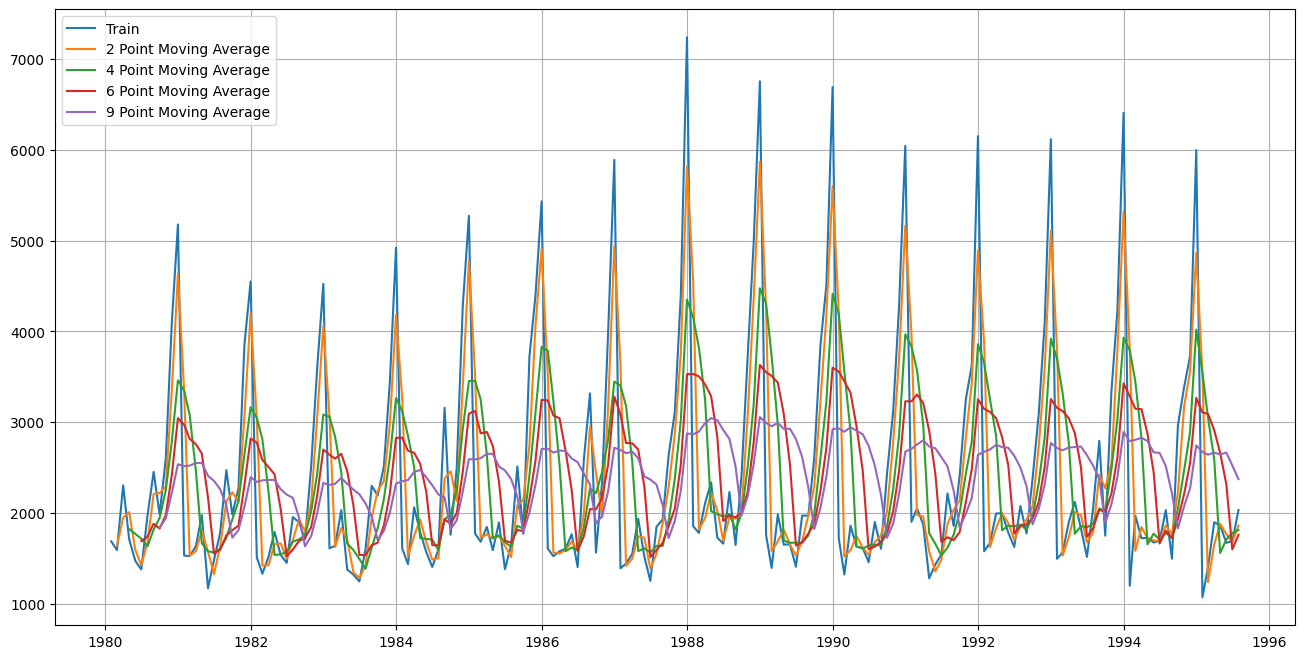

In [ ]:
## Plotting on the whole data

plt.figure(figsize=(16,8))
plt.plot(MovingAverage['Sparkling'], label='Train')
plt.plot(MovingAverage['Trailing_2'], label='2 Point Moving Average')
plt.plot(MovingAverage['Trailing_4'], label='4 Point Moving Average')
plt.plot(MovingAverage['Trailing_6'],label = '6 Point Moving Average')
plt.plot(MovingAverage['Trailing_9'],label = '9 Point Moving Average')

plt.legend(loc = 'best')
plt.grid();

Let us split the data into train and test and plot this Time Series. The window of the moving average is need to be carefully selected as too big a window will result in not having any test set as the whole series might get averaged over.

In [ ]:
# Making a copy of the data to perform the moving average
#Creating train and test set

trailing_MovingAverage_train=MovingAverage[MovingAverage.index.year < 1993]
trailing_MovingAverage_test=MovingAverage[MovingAverage.index.year >= 1993]

In [ ]:
trailing_MovingAverage_train.head()

,Sparkling,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Time_Stamp,,,,,
1980-01-31,1686,NaN,NaN,NaN,NaN
1980-02-29,1591,1638.5,NaN,NaN,NaN
1980-03-31,2304,1947.5,NaN,NaN,NaN
1980-04-30,1712,2008.0,1823.25,NaN,NaN
1980-05-31,1471,1591.5,1769.50,NaN,NaN


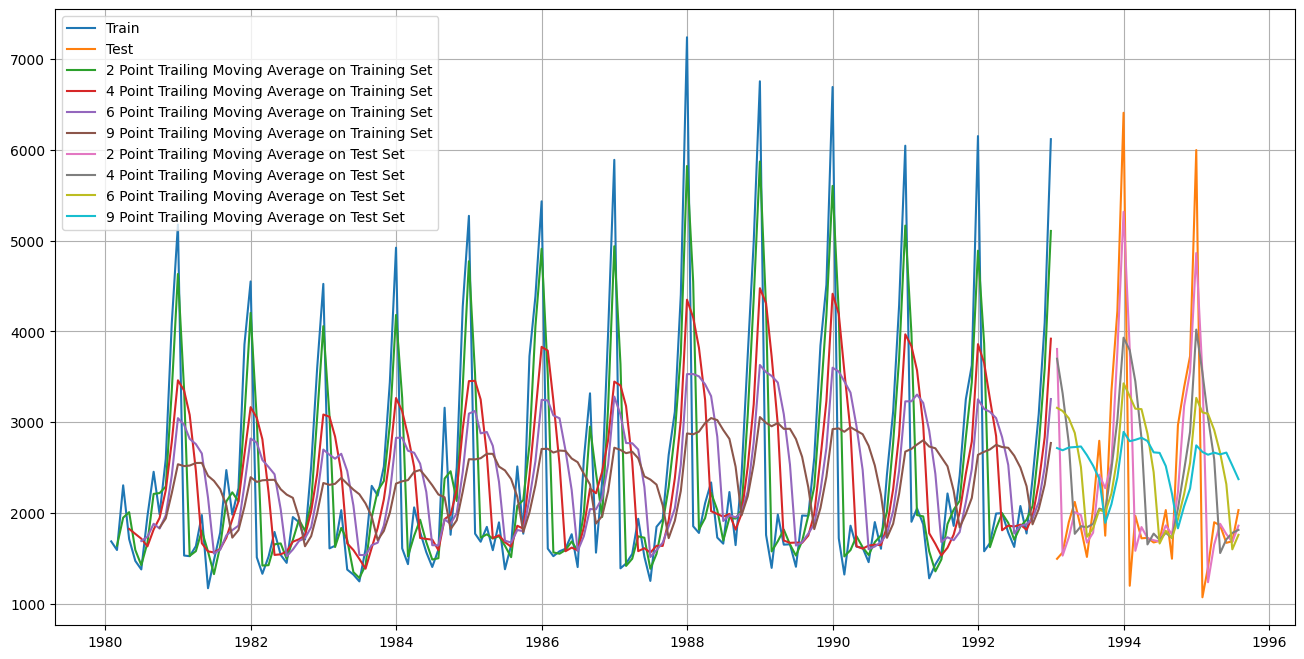

In [ ]:
# Trailing moving averages for 2,4,6,9 months

plt.figure(figsize=(16,8))
plt.plot(trailing_MovingAverage_train['Sparkling'], label='Train')
plt.plot(trailing_MovingAverage_test['Sparkling'], label='Test')

plt.plot(trailing_MovingAverage_train['Trailing_2'], label='2 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_4'], label='4 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_6'],label = '6 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_9'],label = '9 Point Trailing Moving Average on Training Set')

plt.plot(trailing_MovingAverage_test['Trailing_2'], label='2 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_4'], label='4 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_6'],label = '6 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_9'],label = '9 Point Trailing Moving Average on Test Set')
plt.legend(loc = 'best')
plt.grid();

### Model Evaluation
Done only on the test data.

In [ ]:
# Calculating the RMSE of the test data to determie model performance

# 2 point Trailing MA
mse_2 = metrics.mean_squared_error(test['Sparkling'], trailing_MovingAverage_test['Trailing_2'])
rmse_model4_test_2 = np.sqrt(mse_2)
print("For 2 point Moving Average Model forecast on the Test Data,  RMSE is %3.3f" % rmse_model4_test_2)

# 4 point Trailing MA
mse_4 = metrics.mean_squared_error(test['Sparkling'], trailing_MovingAverage_test['Trailing_4'])
rmse_model4_test_4 = np.sqrt(mse_4)
print("For 4 point Moving Average Model forecast on the Test Data,  RMSE is %3.3f" % rmse_model4_test_4)

# 6 point Trailing MA
mse_6 = metrics.mean_squared_error(test['Sparkling'], trailing_MovingAverage_test['Trailing_6'])
rmse_model4_test_6 = np.sqrt(mse_6)
print("For 6 point Moving Average Model forecast on the Test Data,  RMSE is %3.3f" % rmse_model4_test_6)

# 9 point Trailing MA
mse_9 = metrics.mean_squared_error(test['Sparkling'], trailing_MovingAverage_test['Trailing_9'])
rmse_model4_test_9 = np.sqrt(mse_9)
print("For 9 point Moving Average Model forecast on the Test Data,  RMSE is %3.3f" % rmse_model4_test_9)

For 2 point Moving Average Model forecast on the Test Data,  RMSE is 863.303
For 4 point Moving Average Model forecast on the Test Data,  RMSE is 1191.009
For 6 point Moving Average Model forecast on the Test Data,  RMSE is 1287.106
For 9 point Moving Average Model forecast on the Test Data,  RMSE is 1328.360


In [ ]:
# Adding these RMSE results to the results dataframe for comparison later

resultsDf_4 = pd.DataFrame({'Test RMSE': [rmse_model4_test_2,rmse_model4_test_4
                                          ,rmse_model4_test_6,rmse_model4_test_9]}
                           ,index=['2pointTrailingMovingAverage','4pointTrailingMovingAverage'
                                   ,'6pointTrailingMovingAverage','9pointTrailingMovingAverage'])

resultsDf = pd.concat([resultsDf, resultsDf_4])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011
2pointTrailingMovingAverage,863.302735
4pointTrailingMovingAverage,1191.008897
6pointTrailingMovingAverage,1287.105950
9pointTrailingMovingAverage,1328.360056


**Observations**

We build the Moving average models for 2,4,6,9 months averages.  See in the graphs that the 2 point moving average closely follows the original data, although it is not estimating well on the peaks.  The 2 point moving average model is giving the best RMSE of all the models so far.

## Plotting all the models thus far

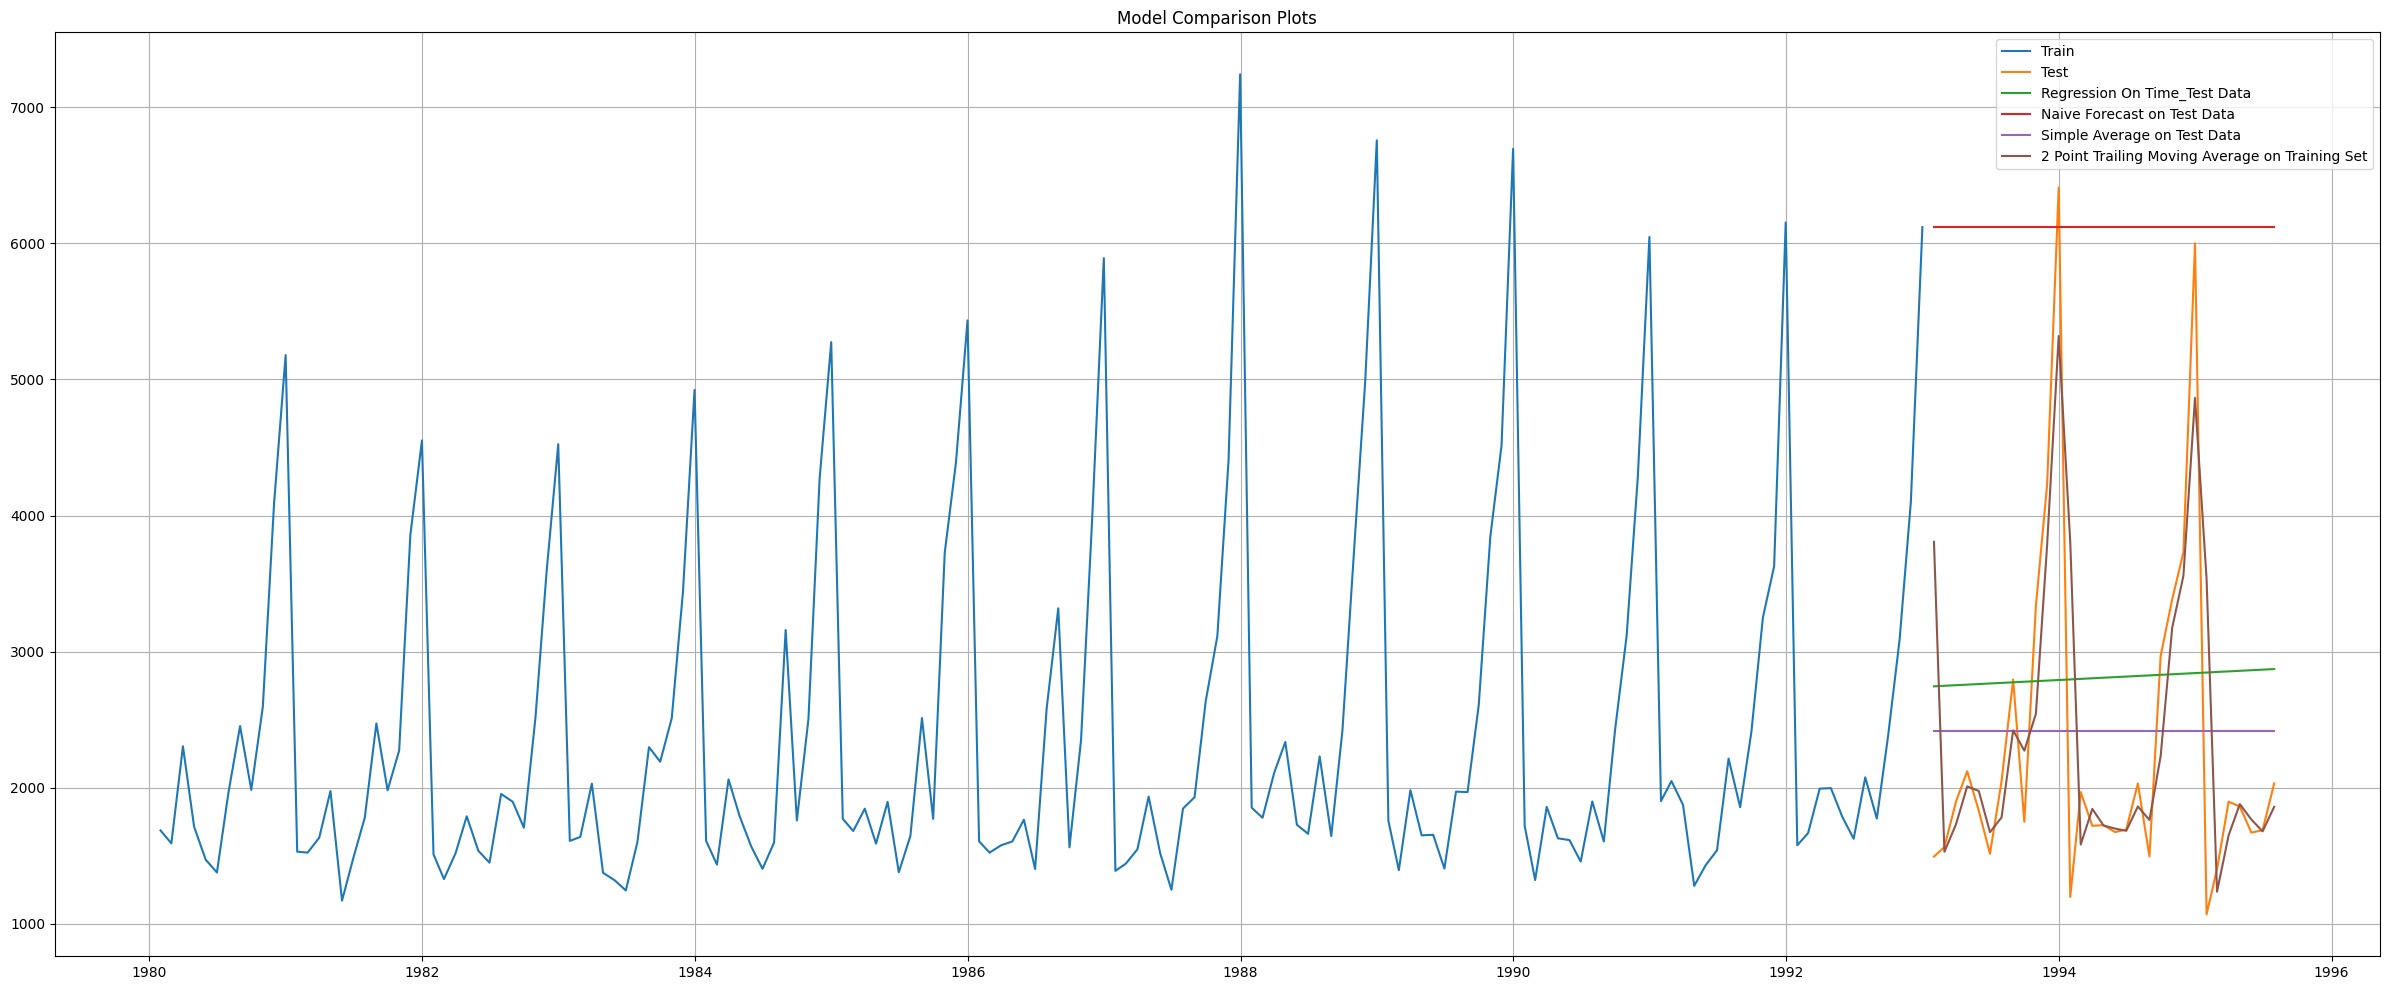

In [ ]:
## Plotting on both Training and Test data

plt.figure(figsize=(30,12))
plt.plot(train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')

plt.plot(LinearRegression_test['RegOnTime'], label='Regression On Time_Test Data')

plt.plot(NaiveModel_test['naive'], label='Naive Forecast on Test Data')

plt.plot(SimpleAverage_test['mean_forecast'], label='Simple Average on Test Data')

plt.plot(trailing_MovingAverage_test['Trailing_2'], label='2 Point Trailing Moving Average on Training Set')


plt.legend(loc='best')
plt.title("Model Comparison Plots")
plt.grid();

## Method 5 - Simple Exponential Smoothing
SES is used when there is no trend and no seasonality.  

In [ ]:
# importing the relevant libraries
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

In [ ]:
# Copying the training and test data
SES_train = train.copy()
SES_test = test.copy()

In [ ]:
# Initializing the SES model with the training data
model_SES = SimpleExpSmoothing(SES_train['Sparkling'])

In [ ]:
# Fitting the model
model_SES_autofit = model_SES.fit(optimized=True)

In [ ]:
model_SES_autofit.params

{'smoothing_level': np.float64(0.0351576224169293),
 'smoothing_trend': np.float64(nan),
 'smoothing_seasonal': np.float64(nan),
 'damping_trend': nan,
 'initial_level': np.float64(1686.0),
 'initial_trend': np.float64(nan),
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

**Observations**

* From the results we see the aplha value is 0.035 which means that not much weight is given to the most recent forecasts.
* The smoothing_trend and smoothing_seasonal is nan because the SES model does not consider trend and seasonality, only level.



In [ ]:
# Predicting on the test data
SES_test['predict'] = model_SES_autofit.forecast(steps=len(test))
SES_test.head()

,Sparkling,predict
Time_Stamp,,
1993-01-31,1494,2632.921331
1993-02-28,1564,2632.921331
1993-03-31,1898,2632.921331
1993-04-30,2121,2632.921331
1993-05-31,1831,2632.921331


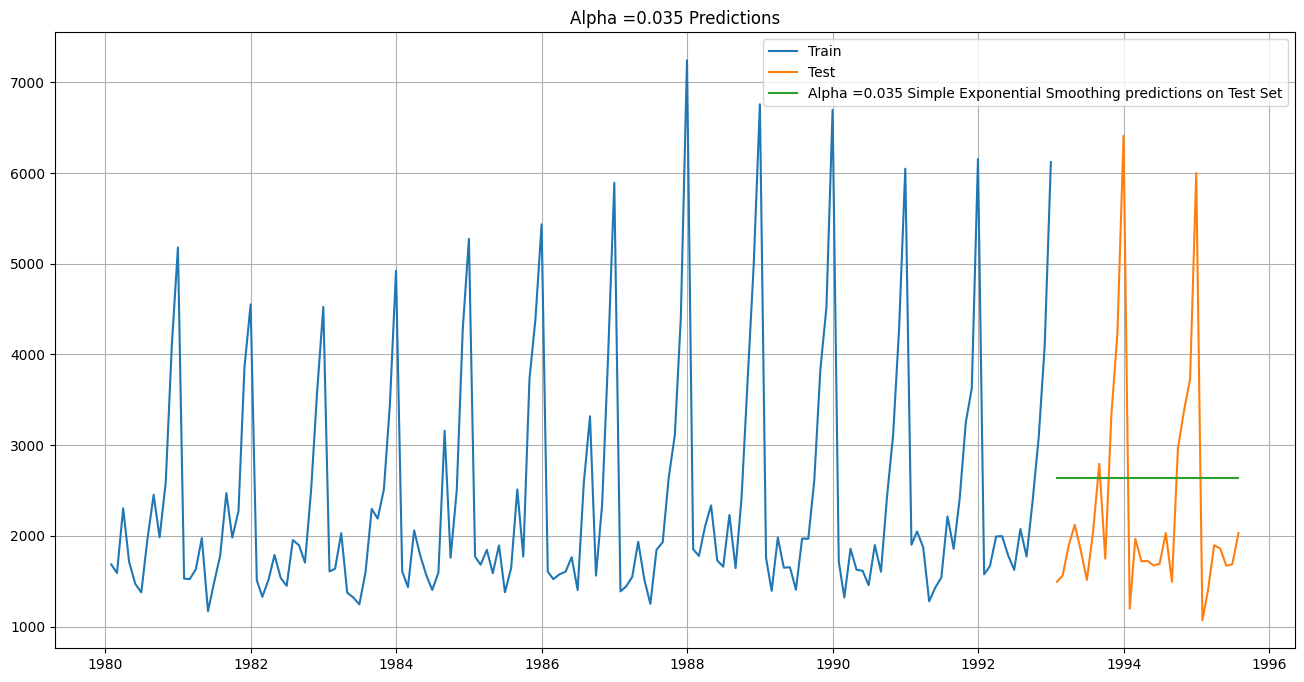

In [ ]:
## Plotting on both the Training and Test data

plt.figure(figsize=(16,8))
plt.plot(SES_train['Sparkling'], label='Train')
plt.plot(SES_test['Sparkling'], label='Test')

plt.plot(SES_test['predict'], label='Alpha =0.035 Simple Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Alpha =0.035 Predictions');

### Model Evaluation for $\alpha$ = 0.035 : Simple Exponential Smoothing

In [ ]:
## Test Data

mse_model5_test_1 = metrics.mean_squared_error(SES_test['Sparkling'], SES_test['predict'])
rmse_model5_test_1 = np.sqrt(mse_model5_test_1)

print("For Alpha = 0.035 Simple Exponential Smoothing Model forecast on the Test Data, RMSE is %3.3f" % rmse_model5_test_1)

For Alpha = 0.035 Simple Exponential Smoothing Model forecast on the Test Data, RMSE is 1291.389


In [ ]:
resultsDf_5 = pd.DataFrame({'Test RMSE': [rmse_model5_test_1]},index=['Alpha=0.035,SimpleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_5])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011
2pointTrailingMovingAverage,863.302735
4pointTrailingMovingAverage,1191.008897
6pointTrailingMovingAverage,1287.105950
9pointTrailingMovingAverage,1328.360056
"Alpha=0.035,SimpleExponentialSmoothing",1291.389234


#### Setting different alpha values.

Remember, the higher the alpha value more weightage is given to the more recent observation. That means, what happened recently will happen again.


We will run a loop with different alpha values to understand which particular value works best for alpha on the test set.

In [ ]:
## First we will define an empty dataframe to store our values from the loop

resultsDf_6 = pd.DataFrame({'Alpha Values':[],'Train RMSE':[],'Test RMSE': []})
resultsDf_6

,Alpha Values,Train RMSE,Test RMSE


In [ ]:
# Performing a grid search of different values of alpha (Level) to determine the best value for the performance on the training and test data RMSE

results_list = []

for i in np.arange(0.01, 1, 0.01):
    alpha_str = f'predict_{i:.1f}'  # e.g., 'predict_0.3'

    model_SES_alpha_i = model_SES.fit(smoothing_level=i, optimized=False, use_brute=True)

    SES_train[alpha_str] = model_SES_alpha_i.fittedvalues
    SES_test[alpha_str] = model_SES_alpha_i.forecast(steps=31)

    mse_train = metrics.mean_squared_error(SES_train['Sparkling'], SES_train[alpha_str])
    rmse_train = np.sqrt(mse_train)

    mse_test = metrics.mean_squared_error(SES_test['Sparkling'], SES_test[alpha_str])
    rmse_test = np.sqrt(mse_test)

    results_list.append({'Alpha Values': i, 'Train RMSE': rmse_train, 'Test RMSE': rmse_test})

resultsDf_6 = pd.DataFrame(results_list)
print(resultsDf_6)

    Alpha Values   Train RMSE    Test RMSE
0           0.01  1354.766714  1255.085516
1           0.02  1324.943306  1270.648467
2           0.03  1318.148055  1285.480135
3           0.04  1317.944850  1296.469202
4           0.05  1320.061031  1306.710548
..           ...          ...          ...
94          0.95  1380.089823  3894.167085
95          0.96  1382.196948  3914.225426
96          0.97  1384.378322  3934.087239
97          0.98  1386.635326  3953.756498
98          0.99  1388.969432  3973.237073

[99 rows x 3 columns]


## Model Evaluation

In [ ]:
resultsDf_6.sort_values(by=['Test RMSE'],ascending=True)

,Alpha Values,Train RMSE,Test RMSE
0,0.01,1354.766714,1255.085516
1,0.02,1324.943306,1270.648467
2,0.03,1318.148055,1285.480135
3,0.04,1317.944850,1296.469202
4,0.05,1320.061031,1306.710548
...,...,...,...
94,0.95,1380.089823,3894.167085
95,0.96,1382.196948,3914.225426
96,0.97,1384.378322,3934.087239
97,0.98,1386.635326,3953.756498


**Observations**

We see that when alpha = 0.01 we get the best RMSE on the testing data

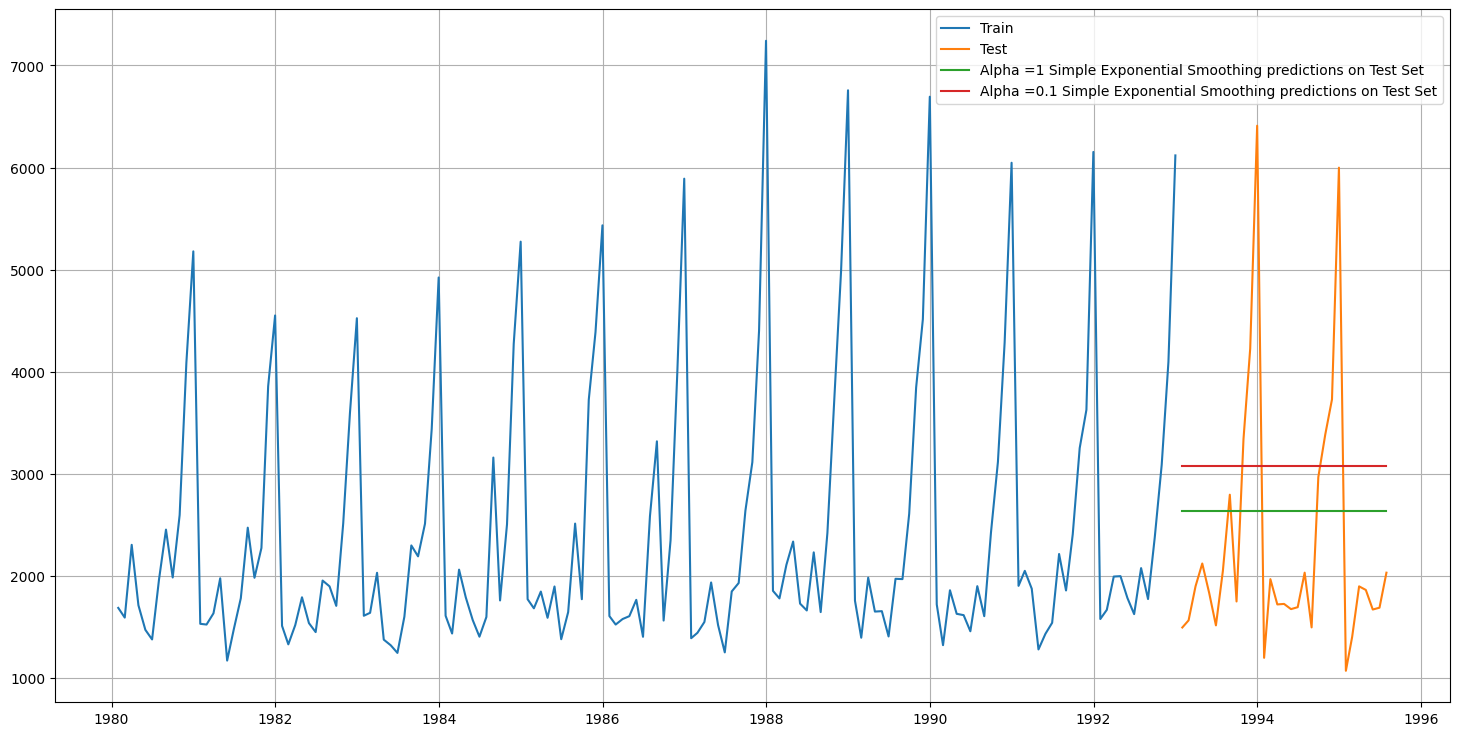

In [ ]:
## Plotting on both the Training and Test data

plt.figure(figsize=(18,9))
plt.plot(SES_train['Sparkling'], label='Train')
plt.plot(SES_test['Sparkling'], label='Test')

plt.plot(SES_test['predict'], label='Alpha =1 Simple Exponential Smoothing predictions on Test Set')

plt.plot(SES_test['predict_0.1'], label='Alpha =0.1 Simple Exponential Smoothing predictions on Test Set')



plt.legend(loc='best')
plt.grid();

In [ ]:
resultsDf_6_1 = pd.DataFrame({'Test RMSE': [resultsDf_6.sort_values(by=['Test RMSE'],ascending=True).values[0][2]]}
                           ,index=['Alpha=0.01,SimpleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_6_1])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011
2pointTrailingMovingAverage,863.302735
4pointTrailingMovingAverage,1191.008897
6pointTrailingMovingAverage,1287.105950
9pointTrailingMovingAverage,1328.360056
"Alpha=0.035,SimpleExponentialSmoothing",1291.389234
"Alpha=0.01,SimpleExponentialSmoothing",1255.085516


## Method 6: Double Exponential Smoothing (Holt's Model)


##### Two parameters $\alpha$ and $\beta$ are estimated in this model. Level and Trend are accounted for in this model.

In [ ]:
# copying the train and test data for the DES model
DES_train = train.copy()
DES_test = test.copy()

In [ ]:
#Initilizing Holts model
model_DES = Holt(DES_train['Sparkling'])

In [ ]:
## First we will define an empty dataframe to store our values from the loop

resultsDf_7 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Train RMSE':[],'Test RMSE': []})
resultsDf_7

,Alpha Values,Beta Values,Train RMSE,Test RMSE


In [ ]:
# Performing a grid search of different values of alpha (Level) and beta (Trend) to determine
#  the best combination for the performance on the training and test data RMSE

results_list = []

for i in np.arange(0.1, 1.1, 0.1):
    for j in np.arange(0.3, 1.1, 0.1):
        model_DES_alpha_i_j = model_DES.fit(smoothing_level=i, smoothing_trend=j, optimized=False, use_brute=True)

        col_name = f'predict_{i:.1f}_{j:.1f}'

        DES_train[col_name] = model_DES_alpha_i_j.fittedvalues
        DES_test[col_name] = model_DES_alpha_i_j.forecast(steps=31)

        mse_train = metrics.mean_squared_error(DES_train['Sparkling'], DES_train[col_name])
        rmse_train = np.sqrt(mse_train)

        mse_test = metrics.mean_squared_error(DES_test['Sparkling'], DES_test[col_name])
        rmse_test = np.sqrt(mse_test)

        results_list.append({
            'Alpha Values': i,
            'Beta Values': j,
            'Train RMSE': rmse_train,
            'Test RMSE': rmse_test
        })

resultsDf_7 = pd.DataFrame(results_list)
print(resultsDf_7)

    Alpha Values  Beta Values   Train RMSE     Test RMSE
0            0.1          0.3  1442.006214   3064.689908
1            0.1          0.4  1478.933360   3834.260234
2            0.1          0.5  1519.211837   4710.113390
3            0.1          0.6  1564.297711   5500.600211
4            0.1          0.7  1614.990413   6385.754819
..           ...          ...          ...           ...
75           1.0          0.6  1783.385432  31685.178903
76           1.0          0.7  1858.701590  34213.632084
77           1.0          0.8  1940.002615  36465.284796
78           1.0          0.9  2028.918399  38520.469892
79           1.0          1.0  2127.962918  40435.781353

[80 rows x 4 columns]


In [ ]:
# Printing the RMSE values for the combinations of alpha and beta.
resultsDf_7

,Alpha Values,Beta Values,Train RMSE,Test RMSE
0,0.1,0.3,1442.006214,3064.689908
1,0.1,0.4,1478.933360,3834.260234
2,0.1,0.5,1519.211837,4710.113390
3,0.1,0.6,1564.297711,5500.600211
4,0.1,0.7,1614.990413,6385.754819
...,...,...,...,...
75,1.0,0.6,1783.385432,31685.178903
76,1.0,0.7,1858.701590,34213.632084
77,1.0,0.8,1940.002615,36465.284796
78,1.0,0.9,2028.918399,38520.469892


In [ ]:
# Sorting the Test RMSE valuse to find the best performing combination.
resultsDf_7.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Train RMSE,Test RMSE
0,0.1,0.3,1442.006214,3064.689908
1,0.1,0.4,1478.933360,3834.260234
2,0.1,0.5,1519.211837,4710.113390
3,0.1,0.6,1564.297711,5500.600211
4,0.1,0.7,1614.990413,6385.754819


**Observations**
We see that a combiantion of  alpha = 0.1 and beta=0.3 gives the best RMSE on the testing data.

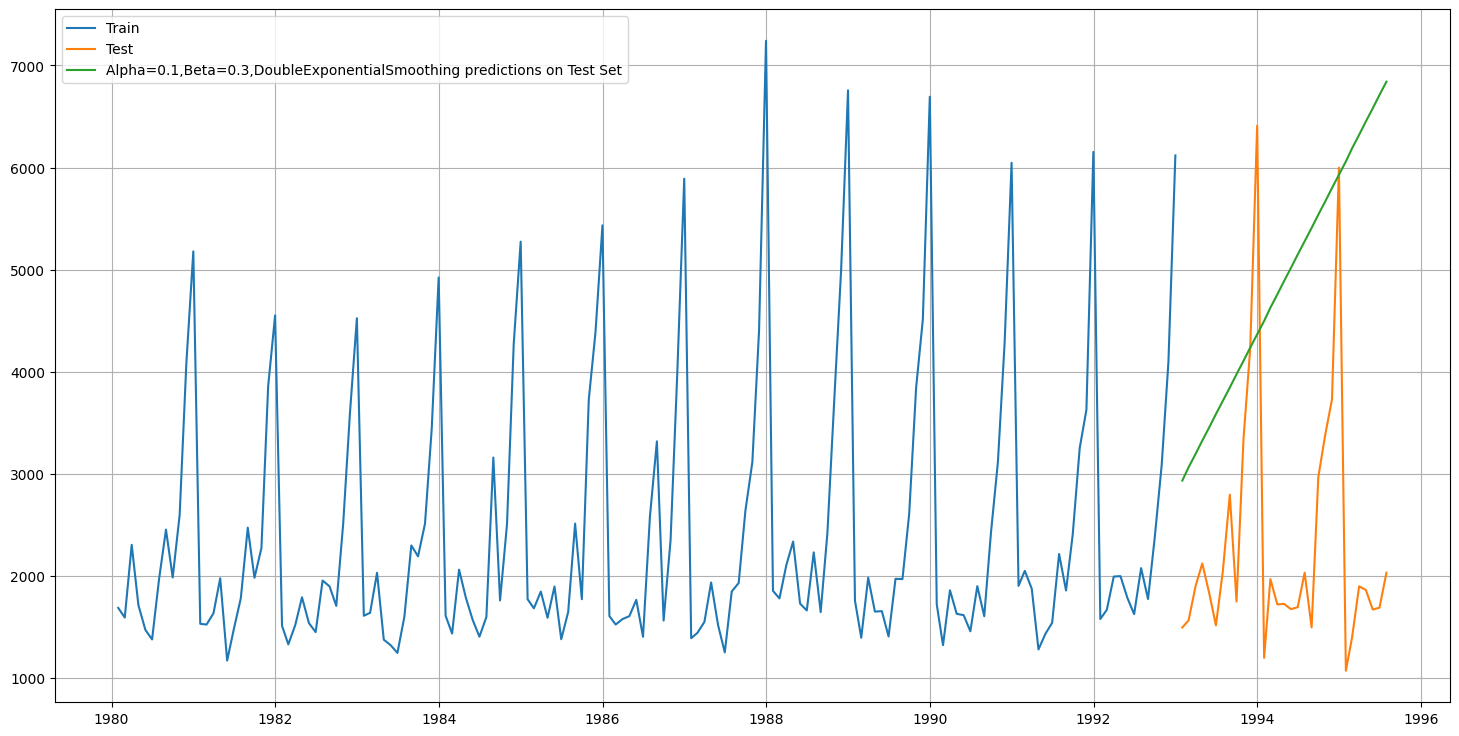

In [ ]:
## Plotting on both the Training and Test data

plt.figure(figsize=(18,9))
plt.plot(DES_train['Sparkling'], label='Train')
plt.plot(DES_test['Sparkling'], label='Test')

plt.plot(DES_test['predict_0.1_0.3'], label='Alpha=0.1,Beta=0.3,DoubleExponentialSmoothing predictions on Test Set')


plt.legend(loc='best')
plt.grid();

**Observtions**
* The upward trend is being captured, however we still don't have the seasonality in the model.  Let us perform the Holt Winters Model to model level, trend and seasonality.

In [ ]:
resultsDf_7_1 = pd.DataFrame({'Test RMSE': [resultsDf_7.sort_values(by=['Test RMSE']).values[0][3]]}
                           ,index=['Alpha=0.1,Beta=0.3,DoubleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_7_1])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011
2pointTrailingMovingAverage,863.302735
4pointTrailingMovingAverage,1191.008897
6pointTrailingMovingAverage,1287.105950
9pointTrailingMovingAverage,1328.360056
"Alpha=0.035,SimpleExponentialSmoothing",1291.389234
"Alpha=0.01,SimpleExponentialSmoothing",1255.085516
"Alpha=0.1,Beta=0.3,DoubleExponentialSmoothing",3064.689908


## Method 7: Triple Exponential Smoothing (Holt - Winter's Model)

##### Three parameters $\alpha$, $\beta$ and $\gamma$ are estimated in this model. Level, Trend and Seasonality are accounted for in this model.

---



In [ ]:
# Making a copy of the train and test data for the Holt Winters Model
TES_train = train.copy()
TES_test = test.copy()

In [ ]:
model_TES = ExponentialSmoothing(TES_train['Sparkling'],trend='additive',seasonal='multiplicative',freq='M')

In [ ]:
model_TES_autofit = model_TES.fit()

In [ ]:
# printing the vest model paramenters as determined by python
model_TES_autofit.params

{'smoothing_level': np.float64(0.07603053904021945),
 'smoothing_trend': np.float64(0.07600390531944044),
 'smoothing_seasonal': np.float64(0.30813889457535076),
 'damping_trend': nan,
 'initial_level': np.float64(2355.7377369762557),
 'initial_trend': np.float64(-16.888651573168907),
 'initial_seasons': array([0.72380717, 0.69288462, 0.90128071, 0.80909662, 0.66610528,
        0.65734959, 0.88402862, 1.14407634, 0.95417061, 1.24909483,
        1.93349639, 2.49361218]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

**Observations**
*  We see that seasonality plays a bigger role in the data than level or trend.
*  Level and trend appears to be equally important and has a smaller value, indicating the time series is less influenced by recent data and has a more stale trend.

In [ ]:
## Prediction on the test data

TES_test['auto_predict'] = model_TES_autofit.forecast(steps=len(test))
TES_test.head()

,Sparkling,auto_predict
Time_Stamp,,
1993-01-31,1494,1713.109868
1993-02-28,1564,1670.005416
1993-03-31,1898,1916.646252
1993-04-30,2121,1742.012894
1993-05-31,1831,1638.083216


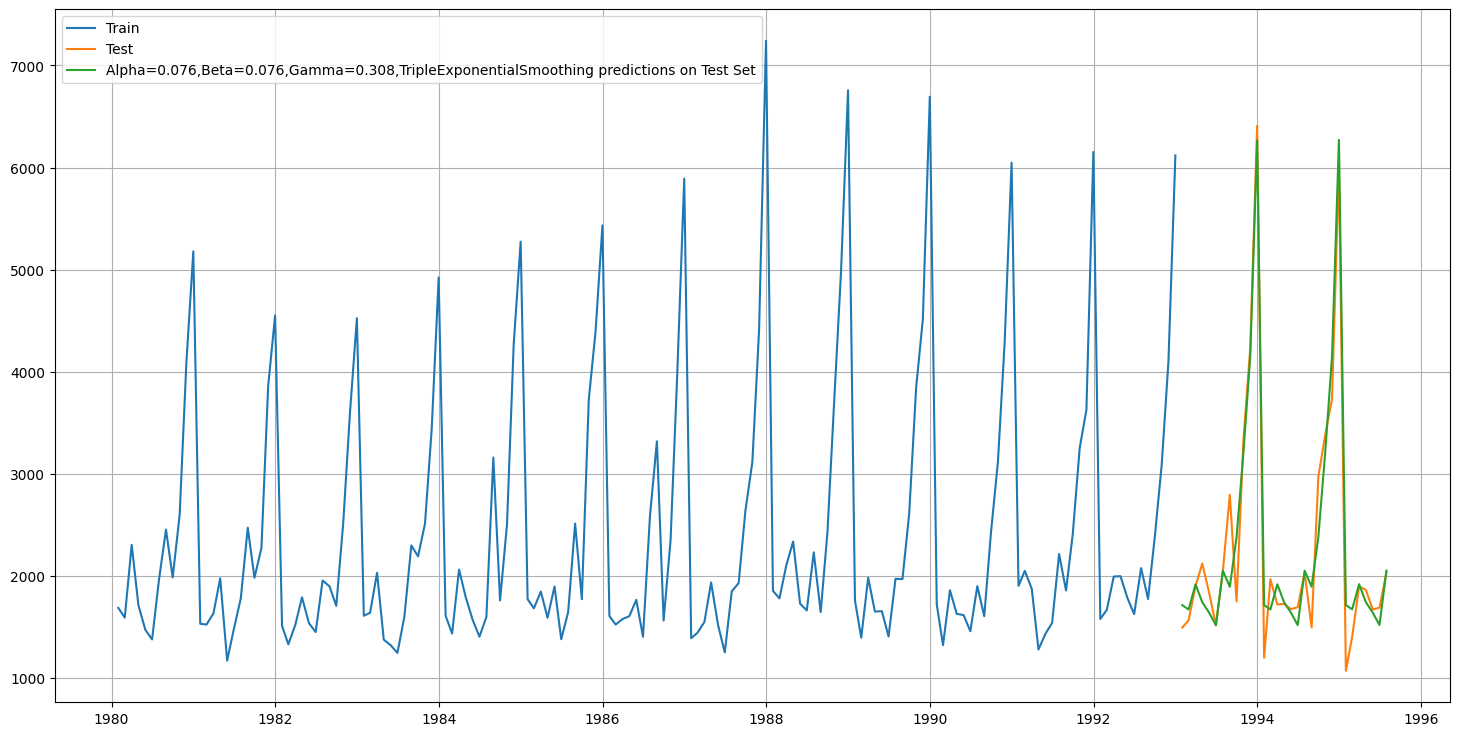

In [ ]:
## Plotting on both the Training and Test using autofit

plt.figure(figsize=(18,9))
plt.plot(TES_train['Sparkling'], label='Train')
plt.plot(TES_test['Sparkling'], label='Test')

plt.plot(TES_test['auto_predict'], label='Alpha=0.076,Beta=0.076,Gamma=0.308,TripleExponentialSmoothing predictions on Test Set')


plt.legend(loc='best')
plt.grid();

**Observations**
We see that the Holt Winters model is fitting the test data the best so far.  We can see the seasonality being modeled.

In [ ]:
## Test Data

mse_model6_test_1 = metrics.mean_squared_error(TES_test['Sparkling'], TES_test['auto_predict'])
rmse_model6_test_1 = np.sqrt(mse_model6_test_1)

print("For Alpha=0.076, Beta=0.076, Gamma=0.308, Triple Exponential Smoothing Model forecast on the Test Data, RMSE is %3.3f" % rmse_model6_test_1)

For Alpha=0.076, Beta=0.076, Gamma=0.308, Triple Exponential Smoothing Model forecast on the Test Data, RMSE is 322.969


In [ ]:
# Adding the TES RMSE to the results dataframe
resultsDf_8_1 = pd.DataFrame({'Test RMSE': [rmse_model6_test_1]}
                           ,index=['Alpha=0.076,Beta=0.076,Gamma=0.308,TripleExponentialSmoothing Automatic'])

resultsDf = pd.concat([resultsDf, resultsDf_8_1])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011
2pointTrailingMovingAverage,863.302735
4pointTrailingMovingAverage,1191.008897
6pointTrailingMovingAverage,1287.105950
9pointTrailingMovingAverage,1328.360056
"Alpha=0.035,SimpleExponentialSmoothing",1291.389234
"Alpha=0.01,SimpleExponentialSmoothing",1255.085516
"Alpha=0.1,Beta=0.3,DoubleExponentialSmoothing",3064.689908


**Observations**
The Holt Winters Model (Triple Exponential Smoothing) has given us the best RMSE so far on the test data.

In [ ]:
# We will now try to find the best values for alpha, beta and gamma by creating a gridsearch
# First we will define an empty dataframe to store our values from the loop

resultsDf_8_2 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Gamma Values':[],'Train RMSE':[],'Test RMSE': []})
resultsDf_8_2

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Test RMSE


In [ ]:
results_list = []

for i in np.arange(0.1, 1.1, 0.1):
    for j in np.arange(0.1, 1.1, 0.1):
        for k in np.arange(0.1, 1.1, 0.1):
            model_TES_alpha_i_j_k = model_TES.fit(
                smoothing_level=i,
                smoothing_trend=j,
                smoothing_seasonal=k,
                optimized=False,
                use_brute=True
            )

            col_name = f'predict_{i:.1f}_{j:.1f}_{k:.1f}'

            TES_train[col_name] = model_TES_alpha_i_j_k.fittedvalues
            TES_test[col_name] = model_TES_alpha_i_j_k.forecast(steps=31)

            mse_train = metrics.mean_squared_error(TES_train['Sparkling'], TES_train[col_name])
            rmse_train = np.sqrt(mse_train)

            mse_test = metrics.mean_squared_error(TES_test['Sparkling'], TES_test[col_name])
            rmse_test = np.sqrt(mse_test)

            results_list.append({
                'Alpha Values': i,
                'Beta Values': j,
                'Gamma Values': k,
                'Train RMSE': rmse_train,
                'Test RMSE': rmse_test
            })

resultsDf_8_2 = pd.DataFrame(results_list)
print(resultsDf_8_2)

     Alpha Values  Beta Values  Gamma Values    Train RMSE     Test RMSE
0             0.1          0.1           0.1  3.727011e+02  3.427588e+02
1             0.1          0.1           0.2  3.563645e+02  3.245677e+02
2             0.1          0.1           0.3  3.513265e+02  3.308245e+02
3             0.1          0.1           0.4  3.527946e+02  3.416191e+02
4             0.1          0.1           0.5  3.582605e+02  3.520167e+02
..            ...          ...           ...           ...           ...
995           1.0          1.0           0.6  1.740796e+05  2.178747e+04
996           1.0          1.0           0.7  2.454886e+05  1.259856e+06
997           1.0          1.0           0.8  1.017383e+06  6.671057e+04
998           1.0          1.0           0.9  1.206713e+05  7.379249e+06
999           1.0          1.0           1.0  2.468673e+04  6.409864e+04

[1000 rows x 5 columns]


In [ ]:
# Sorting results to find the best combiantion of alpha, beta and gamma for the
resultsDf_8_2.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Test RMSE
501,0.6,0.1,0.2,404.620478,316.186034
101,0.2,0.1,0.2,365.220651,323.106292
1,0.1,0.1,0.2,356.364451,324.567745
22,0.1,0.3,0.3,381.484152,324.927106
21,0.1,0.3,0.2,383.472556,327.001235


**Observations**
We see that an alpha = 0.6, beta = 0.1 and gamma = 0.2 is the gives the best RMSE on the test data.

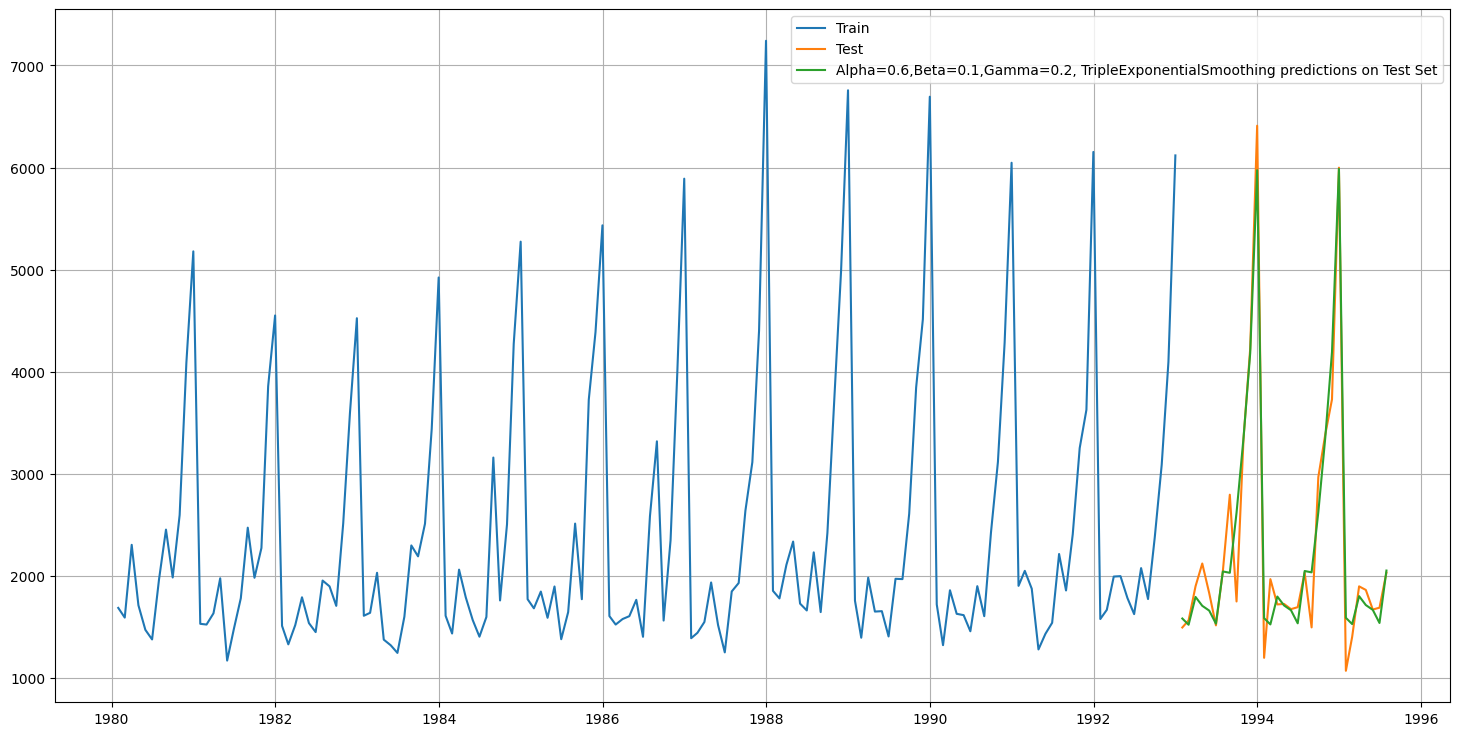

In [ ]:
## Plotting on both the Training and Test data using brute force alpha, beta and gamma determination

plt.figure(figsize=(18,9))
plt.plot(TES_train['Sparkling'], label='Train')
plt.plot(TES_test['Sparkling'], label='Test')

col_name = 'predict_0.6_0.1_0.2'  # Match this to your exact column name!
plt.plot(TES_test[col_name], label='Alpha=0.6,Beta=0.1,Gamma=0.2, TripleExponentialSmoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.show()

**Observations**
We see that the the model is performing well with the gridsearch to find the best RMSE for the test data.  Let us compare the RMSE to the other models.

In [ ]:
resultsDf_8_3 = pd.DataFrame({'Test RMSE': [resultsDf_8_2.sort_values(by=['Test RMSE']).values[0][4]]}
                           ,index=['Alpha=0.6,Beta=0.1,Gamma=0.2,TripleExponentialSmoothing GridSearch'])

resultsDf = pd.concat([resultsDf, resultsDf_8_3])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011
2pointTrailingMovingAverage,863.302735
4pointTrailingMovingAverage,1191.008897
6pointTrailingMovingAverage,1287.105950
9pointTrailingMovingAverage,1328.360056
"Alpha=0.035,SimpleExponentialSmoothing",1291.389234
"Alpha=0.01,SimpleExponentialSmoothing",1255.085516
"Alpha=0.1,Beta=0.3,DoubleExponentialSmoothing",3064.689908


**Observations**
The Holt Winters Model (TES) with the hyperparameters for the grid search is performing the best on the RMSE for the training data.  Alpha = 0.6, Beta=0.1 and Gamma=0.2 is giving the best RMSE (so far) on the testing data RSME = 316.19

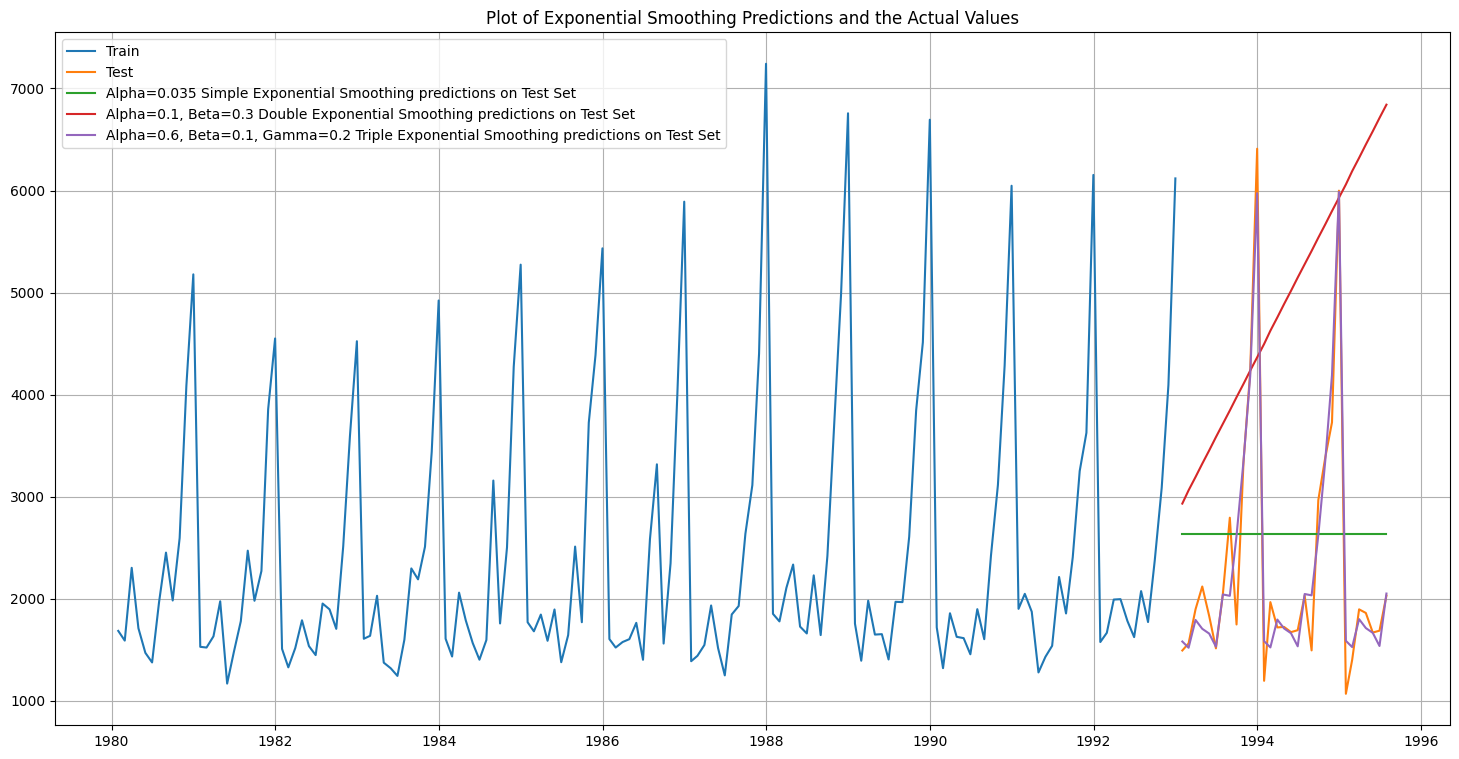

In [ ]:
## Plotting on both the Training and Test data

plt.figure(figsize=(18,9))
plt.plot(train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')

plt.plot(SES_test['predict'], label='Alpha=0.035 Simple Exponential Smoothing predictions on Test Set')

plt.plot(DES_test['predict_0.1_0.3'], label='Alpha=0.1, Beta=0.3 Double Exponential Smoothing predictions on Test Set')

plt.plot(TES_test['predict_0.6_0.1_0.2'], label='Alpha=0.6, Beta=0.1, Gamma=0.2 Triple Exponential Smoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid()
plt.title('Plot of Exponential Smoothing Predictions and the Actual Values')
plt.show()

# We will now build ARMA, ARIMA and SARIMA models

We saw above in the EDA that the whole time series was non stationary.  Lets us check the training data seperately.

The time series needs to be stationary for to the ARMA, ARIMA and SARIMA models

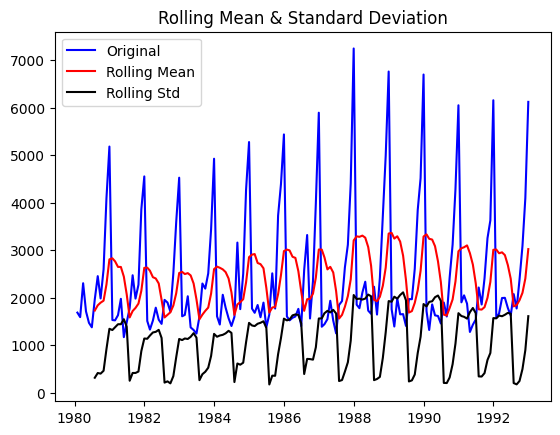

Results of Dickey-Fuller Test:
Test Statistic                  -1.323320
p-value                          0.618437
#Lags Used                      12.000000
Number of Observations Used    143.000000
Critical Value (1%)             -3.476927
Critical Value (5%)             -2.881973
Critical Value (10%)            -2.577665
dtype: float64 



In [ ]:
test_stationarity(train['Sparkling'])

**Observations**
The p value is 0.618 which means that at a 5% significant level we cannot reject the null hypothesis.

We see that the series is not stationary at $\alpha$ = 0.05.

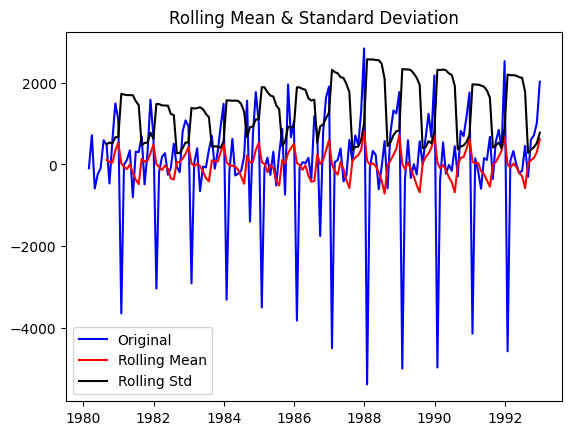

Results of Dickey-Fuller Test:
Test Statistic                -9.035900e+00
p-value                        5.290544e-15
#Lags Used                     1.100000e+01
Number of Observations Used    1.430000e+02
Critical Value (1%)           -3.476927e+00
Critical Value (5%)           -2.881973e+00
Critical Value (10%)          -2.577665e+00
dtype: float64 



In [ ]:
# differencing the data to see if we can make the training data stationary.
test_stationarity(train['Sparkling'].diff().dropna())

**Observations**
We see that after taking a difference of order 1 the series have
become stationary at $\alpha$ = 0.05.

**Note**

If the series is non-stationary, stationarize the Time Series by taking a difference of the Time Series. Then we can use this particular differenced series to train the ARIMA models. We do not need to worry about stationarity for the Test Data because we are not building any models on the Test Data, we are evaluating our models over there.

## Build an Automated version of an <font color='blue'>ARMA model</font> for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

In [ ]:
## The following loop helps us in getting a combination of different parameters of p and q in the range of 0 and 6
## We have kept the value of d as 0 as we necessary for an ARMA model

import itertools
p = q = range(0, 7)
d= range(1)
pdq = list(itertools.product(p, d, q))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 0, 1)
Model: (0, 0, 2)
Model: (0, 0, 3)
Model: (0, 0, 4)
Model: (0, 0, 5)
Model: (0, 0, 6)
Model: (1, 0, 0)
Model: (1, 0, 1)
Model: (1, 0, 2)
Model: (1, 0, 3)
Model: (1, 0, 4)
Model: (1, 0, 5)
Model: (1, 0, 6)
Model: (2, 0, 0)
Model: (2, 0, 1)
Model: (2, 0, 2)
Model: (2, 0, 3)
Model: (2, 0, 4)
Model: (2, 0, 5)
Model: (2, 0, 6)
Model: (3, 0, 0)
Model: (3, 0, 1)
Model: (3, 0, 2)
Model: (3, 0, 3)
Model: (3, 0, 4)
Model: (3, 0, 5)
Model: (3, 0, 6)
Model: (4, 0, 0)
Model: (4, 0, 1)
Model: (4, 0, 2)
Model: (4, 0, 3)
Model: (4, 0, 4)
Model: (4, 0, 5)
Model: (4, 0, 6)
Model: (5, 0, 0)
Model: (5, 0, 1)
Model: (5, 0, 2)
Model: (5, 0, 3)
Model: (5, 0, 4)
Model: (5, 0, 5)
Model: (5, 0, 6)
Model: (6, 0, 0)
Model: (6, 0, 1)
Model: (6, 0, 2)
Model: (6, 0, 3)
Model: (6, 0, 4)
Model: (6, 0, 5)
Model: (6, 0, 6)


In [ ]:
# Creating an empty Dataframe with column names only
ARMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARMA_AIC

,param,AIC


## Method 8: ARMA Model
Build an Automated version of an <font color='blue'>ARMA model</font> for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).



In [ ]:
#Importing the necessary libraries for the ARMA model
from statsmodels.tsa.arima.model import ARIMA

#Creating an empty dataframe to store the AIC results
results = []


# Calacualting the AIC values for the different combinations of p and q
for param in pdq:
    ARMA_model = ARIMA(train['Sparkling'].values, order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param, ARMA_model.aic))
    results.append({'param': param, 'AIC': ARMA_model.aic})


ARMA_AIC = pd.DataFrame(results)

ARIMA(0, 0, 0) - AIC:2683.375885282306
ARIMA(0, 0, 1) - AIC:2655.4223054787726
ARIMA(0, 0, 2) - AIC:2656.0000990297867
ARIMA(0, 0, 3) - AIC:2657.619557518804
ARIMA(0, 0, 4) - AIC:2652.8299300697063
ARIMA(0, 0, 5) - AIC:2653.3806689192934
ARIMA(0, 0, 6) - AIC:2631.517217301287
ARIMA(1, 0, 0) - AIC:2656.875336519145
ARIMA(1, 0, 1) - AIC:2656.020998883274
ARIMA(1, 0, 2) - AIC:2657.2528120844468
ARIMA(1, 0, 3) - AIC:2650.0852525806476
ARIMA(1, 0, 4) - AIC:2659.1274657307017
ARIMA(1, 0, 5) - AIC:2647.5002078255206
ARIMA(1, 0, 6) - AIC:2625.3213523418535
ARIMA(2, 0, 0) - AIC:2654.90149038284
ARIMA(2, 0, 1) - AIC:2642.9803616330355
ARIMA(2, 0, 2) - AIC:2658.850689141983
ARIMA(2, 0, 3) - AIC:2652.7378995188983
ARIMA(2, 0, 4) - AIC:2646.7808006015866
ARIMA(2, 0, 5) - AIC:2640.607234034085
ARIMA(2, 0, 6) - AIC:2633.053502983311
ARIMA(3, 0, 0) - AIC:2656.090777930948
ARIMA(3, 0, 1) - AIC:2644.128143281341
ARIMA(3, 0, 2) - AIC:2639.927307264545
ARIMA(3, 0, 3) - AIC:2652.0235201985224
ARIMA(3, 0, 4

In [ ]:
# Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARMA_AIC.sort_values(by='AIC',ascending=True)

,param,AIC
40,"(5, 0, 5)",2558.205085
46,"(6, 0, 4)",2565.361778
26,"(3, 0, 5)",2576.134761
39,"(5, 0, 4)",2582.139218
33,"(4, 0, 5)",2582.898181
48,"(6, 0, 6)",2583.101003
32,"(4, 0, 4)",2585.256768
45,"(6, 0, 3)",2589.212683
47,"(6, 0, 5)",2591.708124
37,"(5, 0, 2)",2595.314814


**Observations**
From the above method we see that a p = 5, d=0, q=5 gives us the best AIC values.

In [ ]:
# using the best AIC from above to fit the ARMA model
auto_ARIMA = ARIMA(train['Sparkling'], order=(5,0,5),freq='M')

results_auto_ARIMA = auto_ARIMA.fit()

print(results_auto_ARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:              Sparkling   No. Observations:                  156
Model:                 ARIMA(5, 0, 5)   Log Likelihood               -1267.103
Date:                Sat, 05 Jul 2025   AIC                           2558.205
Time:                        14:27:03   BIC                           2594.803
Sample:                    01-31-1980   HQIC                          2573.070
                         - 12-31-1992                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2417.0323     70.475     34.296      0.000    2278.903    2555.162
ar.L1          0.7084      0.057     12.350      0.000       0.596       0.821
ar.L2         -0.2250      0.078     -2.872      0.0

**Observations**
We see that the p values for MA l2 and l3 are very high, suggesting they are not significant in the model. Let us fit the test data and compare the RSME.

In [ ]:
# Performning predictions on the test data
predicted_auto_ARIMA = results_auto_ARIMA.forecast(steps=len(test))

#Importing the necessary libraries
from sklearn.metrics import  mean_squared_error

mse = mean_squared_error(test['Sparkling'], predicted_auto_ARIMA)
rmse = np.sqrt(mse)
print(rmse)

933.0191518240568


In [ ]:
resultsDf_9_1 =pd.DataFrame({'Test RMSE': [rmse]}
                           ,index=['ARIMA(5,0,5)'])

resultsDf = pd.concat([resultsDf, resultsDf_9_1])
resultsDf





,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011
2pointTrailingMovingAverage,863.302735
4pointTrailingMovingAverage,1191.008897
6pointTrailingMovingAverage,1287.105950
9pointTrailingMovingAverage,1328.360056
"Alpha=0.035,SimpleExponentialSmoothing",1291.389234
"Alpha=0.01,SimpleExponentialSmoothing",1255.085516
"Alpha=0.1,Beta=0.3,DoubleExponentialSmoothing",3064.689908


## Method 9: Build an Automated version of an <font color='blue'>ARIMA model</font> for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

In [ ]:
## The following loop helps us in getting a combination of different parameters of p and q in the range of 0 and 6
## We have kept the value of d as 1 as we need to take a difference of the series to make it stationary.

import itertools
p = q = range(0, 7)
d= range(1,2)
pdq = list(itertools.product(p, d, q))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 1, 1)
Model: (0, 1, 2)
Model: (0, 1, 3)
Model: (0, 1, 4)
Model: (0, 1, 5)
Model: (0, 1, 6)
Model: (1, 1, 0)
Model: (1, 1, 1)
Model: (1, 1, 2)
Model: (1, 1, 3)
Model: (1, 1, 4)
Model: (1, 1, 5)
Model: (1, 1, 6)
Model: (2, 1, 0)
Model: (2, 1, 1)
Model: (2, 1, 2)
Model: (2, 1, 3)
Model: (2, 1, 4)
Model: (2, 1, 5)
Model: (2, 1, 6)
Model: (3, 1, 0)
Model: (3, 1, 1)
Model: (3, 1, 2)
Model: (3, 1, 3)
Model: (3, 1, 4)
Model: (3, 1, 5)
Model: (3, 1, 6)
Model: (4, 1, 0)
Model: (4, 1, 1)
Model: (4, 1, 2)
Model: (4, 1, 3)
Model: (4, 1, 4)
Model: (4, 1, 5)
Model: (4, 1, 6)
Model: (5, 1, 0)
Model: (5, 1, 1)
Model: (5, 1, 2)
Model: (5, 1, 3)
Model: (5, 1, 4)
Model: (5, 1, 5)
Model: (5, 1, 6)
Model: (6, 1, 0)
Model: (6, 1, 1)
Model: (6, 1, 2)
Model: (6, 1, 3)
Model: (6, 1, 4)
Model: (6, 1, 5)
Model: (6, 1, 6)


In [ ]:
# Creating an empty Dataframe with column names only
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARIMA_AIC

,param,AIC


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

results = []

for param in pdq:
    ARIMA_model = ARIMA(train['Sparkling'].values, order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param, ARIMA_model.aic))
    results.append({'param': param, 'AIC': ARIMA_model.aic})

ARIMA_AIC = pd.DataFrame(results)

ARIMA(0, 1, 0) - AIC:2686.667350901008
ARIMA(0, 1, 1) - AIC:2678.9038212820215
ARIMA(0, 1, 2) - AIC:2644.6965523637464
ARIMA(0, 1, 3) - AIC:2644.2973069007176
ARIMA(0, 1, 4) - AIC:2645.8233790176473
ARIMA(0, 1, 5) - AIC:2639.0137313817254
ARIMA(0, 1, 6) - AIC:2635.489954141035
ARIMA(1, 1, 0) - AIC:2683.718309094362
ARIMA(1, 1, 1) - AIC:2645.5075956704495
ARIMA(1, 1, 2) - AIC:2644.909061298944
ARIMA(1, 1, 3) - AIC:2646.1180595456844
ARIMA(1, 1, 4) - AIC:2634.986667924177
ARIMA(1, 1, 5) - AIC:2782.333707881731
ARIMA(1, 1, 6) - AIC:2648.873975415165
ARIMA(2, 1, 0) - AIC:2677.498633653658
ARIMA(2, 1, 1) - AIC:2644.0179550106404
ARIMA(2, 1, 2) - AIC:2623.2211127321143
ARIMA(2, 1, 3) - AIC:2642.6465844793456
ARIMA(2, 1, 4) - AIC:2637.8041693922487
ARIMA(2, 1, 5) - AIC:2718.844608537551
ARIMA(2, 1, 6) - AIC:2634.067822247773
ARIMA(3, 1, 0) - AIC:2674.668784947032
ARIMA(3, 1, 1) - AIC:2645.328013972103
ARIMA(3, 1, 2) - AIC:2640.0162635865418
ARIMA(3, 1, 3) - AIC:2638.8815370471166
ARIMA(3, 1, 

In [ ]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARIMA_AIC.sort_values(by='AIC',ascending=True)

,param,AIC
46,"(6, 1, 4)",2592.081705
48,"(6, 1, 6)",2608.701191
44,"(6, 1, 2)",2614.245176
32,"(4, 1, 4)",2620.774952
16,"(2, 1, 2)",2623.221113
43,"(6, 1, 1)",2625.228177
39,"(5, 1, 4)",2627.427959
45,"(6, 1, 3)",2629.821828
38,"(5, 1, 3)",2632.979623
25,"(3, 1, 4)",2633.880383


In [ ]:
auto_ARIMA = ARIMA(train['Sparkling'], order=(6,1,4),freq='M')

results_auto_ARIMA = auto_ARIMA.fit()

print(results_auto_ARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:              Sparkling   No. Observations:                  156
Model:                 ARIMA(6, 1, 4)   Log Likelihood               -1285.041
Date:                Sat, 05 Jul 2025   AIC                           2592.082
Time:                        14:27:40   BIC                           2625.559
Sample:                    01-31-1980   HQIC                          2605.680
                         - 12-31-1992                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2785      0.069     -4.038      0.000      -0.414      -0.143
ar.L2          0.3243      0.084      3.865      0.000       0.160       0.489
ar.L3          0.2141      0.081      2.627      0.0

In [ ]:
# Test set
predicted_auto_ARIMA = results_auto_ARIMA.forecast(steps=len(test))

from sklearn.metrics import  mean_squared_error
mse = mean_squared_error(test['Sparkling'],predicted_auto_ARIMA)
rmse = np.sqrt(mse)
print(rmse)



1039.7018637915546


In [ ]:
temp_resultsDf0 = pd.DataFrame({'Test RMSE': [rmse]}
                           ,index=['ARIMA(6,1,4)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf0])
resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011
2pointTrailingMovingAverage,863.302735
4pointTrailingMovingAverage,1191.008897
6pointTrailingMovingAverage,1287.105950
9pointTrailingMovingAverage,1328.360056
"Alpha=0.035,SimpleExponentialSmoothing",1291.389234
"Alpha=0.01,SimpleExponentialSmoothing",1255.085516
"Alpha=0.1,Beta=0.3,DoubleExponentialSmoothing",3064.689908


## Build an Automated version of a <font color='blue'>SARIMA</font> model for which the best parameters are selected in accordance with the lowest Akaike Information Criteria (AIC).

Let us look at the ACF plot once more to understand the seasonal parameter for the SARIMA model.

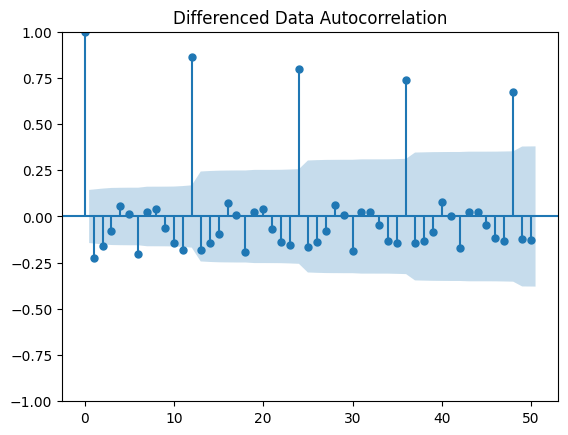

In [ ]:
plot_acf(df['Sparkling'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plt.show()

**Observations**

We see that there can be a seasonality of 12.

We will use 12 for m in the search for the lowest AIC.  
We will find the best combinations for p,q and d.

In [ ]:
import itertools

model_pdq = []

p = q = range(0, 4)
d= range(1,2)
D = range(0,1)
pdq = list(itertools.product(p, d, q))
model_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, D, q))]
print('Examples of some parameter combinations for Model...')
for i in range(1,len(pdq)):
    print('Model: {}{}'.format(pdq[i], model_pdq[i]))


Examples of some parameter combinations for Model...
Model: (0, 1, 1)(0, 0, 1, 12)
Model: (0, 1, 2)(0, 0, 2, 12)
Model: (0, 1, 3)(0, 0, 3, 12)
Model: (1, 1, 0)(1, 0, 0, 12)
Model: (1, 1, 1)(1, 0, 1, 12)
Model: (1, 1, 2)(1, 0, 2, 12)
Model: (1, 1, 3)(1, 0, 3, 12)
Model: (2, 1, 0)(2, 0, 0, 12)
Model: (2, 1, 1)(2, 0, 1, 12)
Model: (2, 1, 2)(2, 0, 2, 12)
Model: (2, 1, 3)(2, 0, 3, 12)
Model: (3, 1, 0)(3, 0, 0, 12)
Model: (3, 1, 1)(3, 0, 1, 12)
Model: (3, 1, 2)(3, 0, 2, 12)
Model: (3, 1, 3)(3, 0, 3, 12)


In [ ]:
SARIMA_AIC = pd.DataFrame(columns=['param','seasonal', 'AIC'])
SARIMA_AIC

,param,seasonal,AIC


In [ ]:
import statsmodels.api as sm

results = []

for param in pdq:
    for param_seasonal in model_pdq:
        SARIMA_model = sm.tsa.statespace.SARIMAX(
            train['Sparkling'].values,
            order=param,
            seasonal_order=param_seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        results_SARIMA = SARIMA_model.fit(maxiter=1000)
        print('SARIMA{}x{} - AIC:{}'.format(param, param_seasonal, results_SARIMA.aic))

        results.append({'param': param, 'seasonal': param_seasonal, 'AIC': results_SARIMA.aic})


SARIMA_AIC = pd.DataFrame(results)


SARIMA(0, 1, 0)x(0, 0, 0, 12) - AIC:2670.3487061846035
SARIMA(0, 1, 0)x(0, 0, 1, 12) - AIC:2356.5521033692735
SARIMA(0, 1, 0)x(0, 0, 2, 12) - AIC:2108.3137845742667
SARIMA(0, 1, 0)x(0, 0, 3, 12) - AIC:1894.0846733564915
SARIMA(0, 1, 0)x(1, 0, 0, 12) - AIC:2198.6999819471766
SARIMA(0, 1, 0)x(1, 0, 1, 12) - AIC:2164.405176111324
SARIMA(0, 1, 0)x(1, 0, 2, 12) - AIC:1987.7736941750686
SARIMA(0, 1, 0)x(1, 0, 3, 12) - AIC:1810.5902552884259
SARIMA(0, 1, 0)x(2, 0, 0, 12) - AIC:2004.2036115208327
SARIMA(0, 1, 0)x(2, 0, 1, 12) - AIC:2003.2632126124545
SARIMA(0, 1, 0)x(2, 0, 2, 12) - AIC:1988.3876412120385
SARIMA(0, 1, 0)x(2, 0, 3, 12) - AIC:1814.16322170525
SARIMA(0, 1, 0)x(3, 0, 0, 12) - AIC:1826.1649105559145
SARIMA(0, 1, 0)x(3, 0, 1, 12) - AIC:1827.8656173904037
SARIMA(0, 1, 0)x(3, 0, 2, 12) - AIC:1828.39866505374
SARIMA(0, 1, 0)x(3, 0, 3, 12) - AIC:1803.0554125369129
SARIMA(0, 1, 1)x(0, 0, 0, 12) - AIC:2645.9239263365166
SARIMA(0, 1, 1)x(0, 0, 1, 12) - AIC:2315.8121231974524
SARIMA(0, 1, 1)

In [ ]:
SARIMA_AIC.sort_values(by=['AIC']).head()

,param,seasonal,AIC
183,"(2, 1, 3)","(1, 0, 3, 12)",1715.869504
55,"(0, 1, 3)","(1, 0, 3, 12)",1717.486760
119,"(1, 1, 3)","(1, 0, 3, 12)",1717.636616
59,"(0, 1, 3)","(2, 0, 3, 12)",1718.480964
123,"(1, 1, 3)","(2, 0, 3, 12)",1718.544488


**Observations**
We see the SARIMA model is giving the best AIC values.  The best combination of hyperparameters are:  p=2, d=1, q=3, P=1, D=0, Q=3 and M=12.  We will build the SARIMA model now

In [ ]:
import statsmodels.api as sm

auto_SARIMA = sm.tsa.statespace.SARIMAX(train['Sparkling'].values,
                                order=(1, 1, 3),
                                seasonal_order=(1, 0, 3, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_auto_SARIMA = auto_SARIMA.fit(maxiter=1000)
print(results_auto_SARIMA.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  156
Model:             SARIMAX(1, 1, 3)x(1, 0, 3, 12)   Log Likelihood                -849.818
Date:                            Sat, 05 Jul 2025   AIC                           1717.637
Time:                                    14:53:11   BIC                           1742.341
Sample:                                         0   HQIC                          1727.664
                                            - 156                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5581      0.388     -1.438      0.150      -1.319       0.202
ma.L1         -0.2450      0.414   

**Observations**

We can see that some of the p values are not significant(ar.L1, ma.L1, ma.L3, ma.S.L12, ma.S.L24, ma.S.L36)

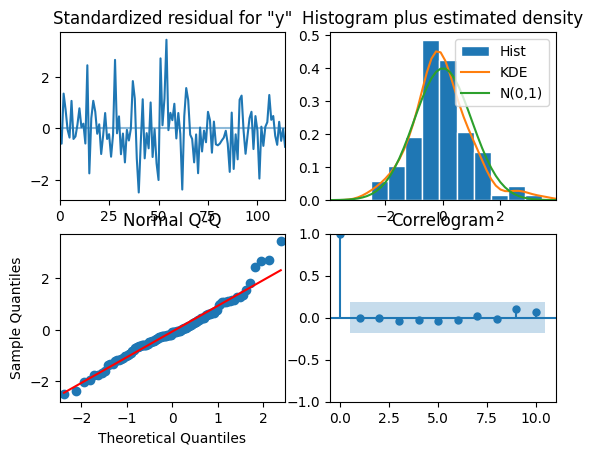

In [ ]:
results_auto_SARIMA.plot_diagnostics()
plt.show()

#### <u>4 plots in the residuals diagnostic plots tell us</u> :

- **Standardized residuals plot**:There is no obvious pattern in the residulas and they fluctuate around 0.



- **Histogram plus estimated density plot**: We see that the residuals is sufficiently normally distributed.



- **Normal Q-Q plot**: From the Q-Q plot we see the residuals follows the red line closely, hence normally distributed



- **Correlogram plot**: The residuals falls in the blue range (95% confidince interval).  This means that there is no siginificant autocorrelation in the residuals.

In [ ]:
len(test)

31

In [ ]:
#Predicting on the test data
predicted_auto_SARIMA = results_auto_SARIMA.get_forecast(steps=len(test))

predicted_auto_SARIMA.summary_frame(alpha=0.05).head()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
0,1571.548628,372.446184,841.567521,2301.529735
1,1728.804689,389.389547,965.615202,2491.994176
2,1927.915097,389.564223,1164.383250,2691.446944
3,1824.777001,392.385642,1055.715274,2593.838728
4,1663.197988,392.125893,894.645360,2431.750617


In [ ]:
#Calculating the RMSE
mse = mean_squared_error(test['Sparkling'],predicted_auto_SARIMA.predicted_mean)
rmse = np.sqrt(mse)
print(rmse)

353.4903081370322


In [ ]:
temp_resultsDf = pd.DataFrame({'Test RMSE': [rmse]}
                           ,index=['SARIMA(2,1,3)(1,0,3,12)'])


resultsDf = pd.concat([resultsDf,temp_resultsDf])

resultsDf

,Test RMSE
RegressionOnTime,1342.992772
NaiveModel,3992.532732
SimpleAverageModel,1258.178011
2pointTrailingMovingAverage,863.302735
4pointTrailingMovingAverage,1191.008897
6pointTrailingMovingAverage,1287.105950
9pointTrailingMovingAverage,1328.360056
"Alpha=0.035,SimpleExponentialSmoothing",1291.389234
"Alpha=0.01,SimpleExponentialSmoothing",1255.085516
"Alpha=0.1,Beta=0.3,DoubleExponentialSmoothing",3064.689908


**Observations**

We see that the best perfomring model as per thr RMSE on the test data is the Triple Exponontial Smoothing with the grid search using Alpha = 0.6, Beta = 0.1 and Gamma = 0.2.  

## Model Comparison and Final Model Selection

In [ ]:
resultsDf.sort_values(by = 'Test RMSE')

,Test RMSE
"Alpha=0.6,Beta=0.1,Gamma=0.2,TripleExponentialSmoothing GridSearch",316.186034
"Alpha=0.076,Beta=0.076,Gamma=0.308,TripleExponentialSmoothing Automatic",322.969287
"SARIMA(2,1,3)(1,0,3,12)",353.490308
2pointTrailingMovingAverage,863.302735
"ARIMA(5,0,5)",933.019152
"ARIMA(6,1,4)",1039.701864
4pointTrailingMovingAverage,1191.008897
"Alpha=0.01,SimpleExponentialSmoothing",1255.085516
SimpleAverageModel,1258.178011
6pointTrailingMovingAverage,1287.105950


**Observations**

We see that the best performing model accouring to the RMSE values of the test data is the Tripple Exponential Model done by Grid Search with Alpha=0.6,Beta=0.1,Gamma=0.2.  The RMSE for this model is 316.18.

## Forecasting using Final Model

We will now use the best model (Triple Exponential Smoothing) to build the most optimal model in the full dataset.

In [ ]:
fullmodel = ExponentialSmoothing(df,
                                  trend='additive',
                                  seasonal='multiplicative').fit(smoothing_level=0.6,
                                                                 smoothing_trend=0.1,
                                                                 smoothing_seasonal=0.2)

In [ ]:
mse = metrics.mean_squared_error(df['Sparkling'], fullmodel.fittedvalues)
rmse_fullmodel = np.sqrt(mse)

print('RMSE:', rmse_fullmodel)

RMSE: 407.69043800784334


**Observations**
The RMSE for the TES model on the full data is 407.69

In [ ]:
# Getting the predictions for the same number of times stamps that are present in the test data
prediction = fullmodel.forecast(steps=12)

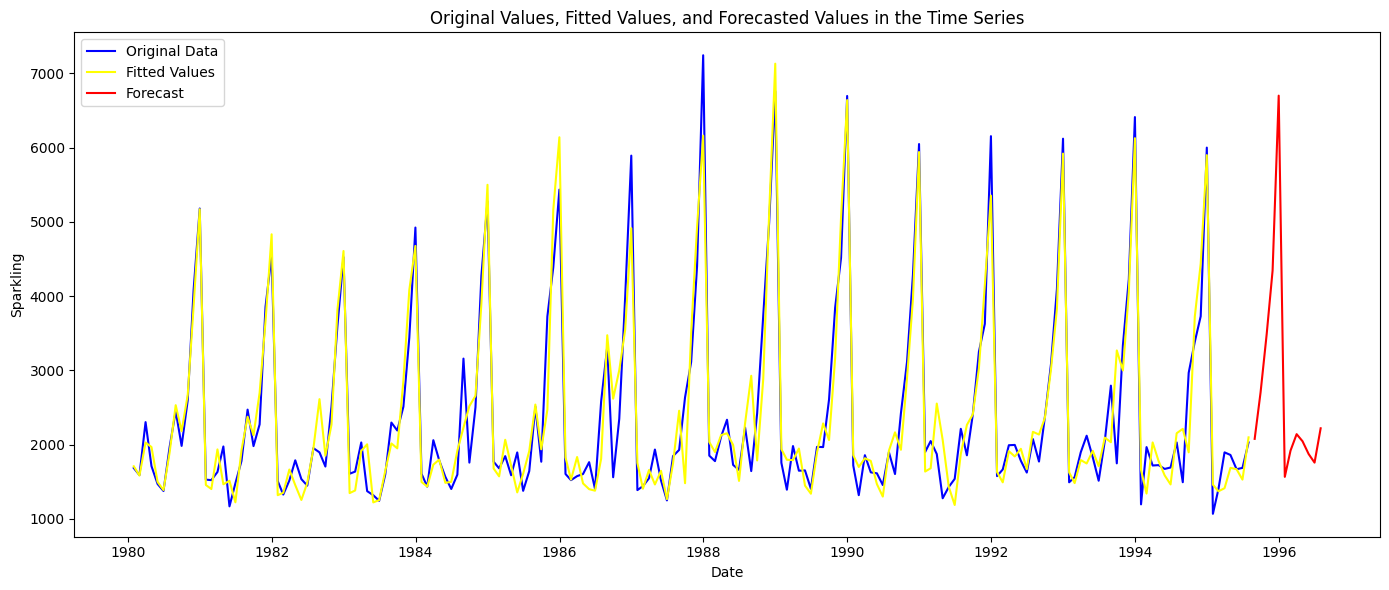

In [ ]:
# Plotting the original data with the predicited values and the forecasted time time series data for 12 months

plt.figure(figsize=(14, 6))

# Plot each line on the same axis and add labels for the legend
plt.plot(df.index, df['Sparkling'], label='Original Data', color='blue')
plt.plot(fullmodel.fittedvalues.index, fullmodel.fittedvalues, label='Fitted Values', color='yellow')
plt.plot(prediction.index, prediction, label='Forecast', color='red')

# Add title, legend, and grid
plt.title('Original Values, Fitted Values, and Forecasted Values in the Time Series')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('Sparkling')

plt.tight_layout()
plt.show()

**Observations**
* We see that the Fitted values follows closely with the original time series.
* For some months the peaks are being over estimated, some months the peaks are underestimates and some are fitted well.
* The forecasted data follows the same pattern as the original data.

In [ ]:
#In the below code, we have calculated the upper and lower confidence bands at 95% confidence level
#The percentile function under numpy lets us calculate these and adding and subtracting from the predictions
#gives us the necessary confidence bands for the predictions
pred_2_df = pd.DataFrame({'lower_CI':prediction - 1.96*np.std(fullmodel.resid,ddof=1),
                          'prediction':prediction,
                          'upper_ci': prediction + 1.96*np.std(fullmodel.resid,ddof=1)})
pred_2_df.head()

,lower_CI,prediction,upper_ci
1995-08-31,1277.415163,2078.621974,2879.828786
1995-09-30,1904.207804,2705.414615,3506.621427
1995-10-31,2687.118221,3488.325033,4289.531844
1995-11-30,3542.751866,4343.958678,5145.165489
1995-12-31,5897.171482,6698.378293,7499.585105


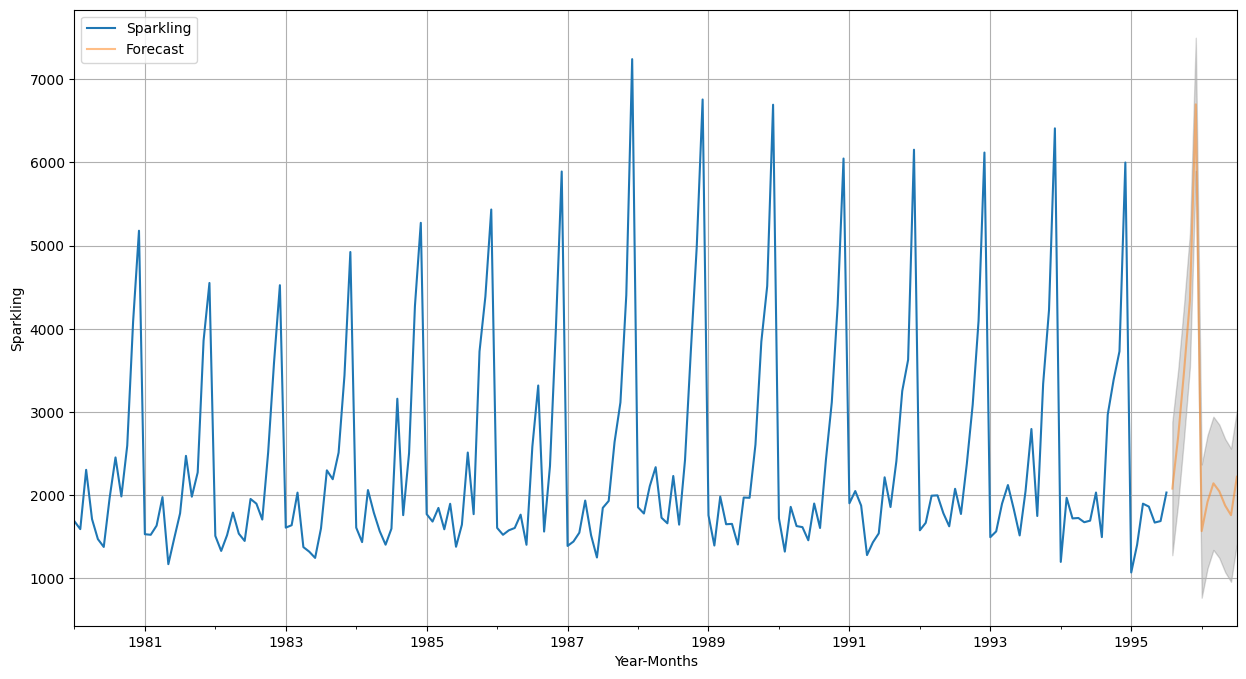

In [ ]:
# plot the forecast along with the confidence band

axis = df.plot(label='Actual', figsize=(15,8))
pred_2_df['prediction'].plot(ax=axis, label='Forecast', alpha=0.5)
axis.fill_between(pred_2_df.index, pred_2_df['lower_CI'], pred_2_df['upper_ci'], color='k', alpha=.15)
axis.set_xlabel('Year-Months')
axis.set_ylabel('Sparkling')
plt.legend(loc='best')
plt.grid()
plt.show()

##Summary
We started this time series analysis by adding a time stamp to prepare the data for time series processing,  We did a basic EDA where we looked at duplicate and missing values, nan's, outliers and stationarity.  We explored the data using graphs which showed the yearly and monthly boxplots and empirical cummulative distribution in the data.  We then decomposed the time series using both addative and multiplicative trends.    


In order to start the modelling process and to prevent data leaks we then split the time series in to train and test where the training data was dates before 1993 and testing data was from 1993 onwards.  We then built different models including regression, naive forecast, simple average, exponential smoothing (single, double and triple), ARMA, ARIMA and SARIMA models.  

The final model chosen, The Triple Exponential Smooting using Grid Search proved to have the lowest RMSE on test data and the residuals showed to have a normal distribution with no autocorrelation.  This indicates that the model is a strong model.


### Business Insights
*  There is a seasonality and a slight upward trend in the sales of Sparkling
*  From the ACF plots we can see that there is a seasonality of 12 months.  We also see some repeating pattern every 6 months where the correlation is negative.  This indicates that every 6 months the sales drop.
* From the decomposition we can see that the trend is addative as it appears to be steady.  


## Recommendations
* As there is a general upward trend there is an opportunity to advertise in the months where sales tend to increase in order to maximize on the increase in sales and keep the trend upward.
* The forecast model provides a reliable indicatoion of future need so that ABC Estate Wines can do inventory planning, staff planning, promotions and marketing, especially in busy months.
*  In the months were the salesa are forecased to decrease, ABC Estate Wines can add promotions and include other services to boost wine sales such as vinyard tours.
* It is always a good idea to perform maintance on these models with real time data to improve forecast.

__________